In [59]:
import random
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt

from pathlib import Path
from impisc.impisc.et_daqbox import daq_box_api as dba

In [60]:
Temp_gain = Path('calibration/T_gain_curve')

#### Function

In [61]:
def gauss(x, mu, amp, wid):
    return amp * np.exp(-(x - mu)**2 / wid**2)

def spec_parse(fn, PACKET_SIZE):
    spectra = []

    with open(fn, "rb") as f:
        while True:
            data = f.read(PACKET_SIZE)
            if len(data) == 0:
                # Hit end of file
                break
            spectra.append(dba.parse_spectrum_packet(data))
        
    return np.array(spectra)

def wf_parse(fn, PACKET_SIZE):
    waveforms = []

    with open(fn, "rb") as f:
        while True:
            data = f.read(PACKET_SIZE)
            if len(data) == 0:
                # Hit end of file
                break
            waveforms.append(dba.parse_waveform_packet(data))
    return waveforms

def baseline_and_noise(waveform, pre_pulse=80):
    baseline = np.median(waveform[:pre_pulse])
    noise = np.std(waveform[:pre_pulse])
    waveform -= baseline
    return baseline, noise, waveform

def good_waveform(waveform, pre_pulse=80):
    _, _, waveform_adj = baseline_and_noise(waveform, 80)
    
    amp = np.max(np.abs(waveform_adj))

    if amp > 1000: # maximum ADC
        return False
    
    return True

def integrate_charge(waveform, t, t_lo=100, t_hi=150):
    baseline, noise, waveform_adj = baseline_and_noise(waveform)
    int_win = (t >= t_lo) & (t <= t_hi)
    return waveform_adj[int_win].sum()

def get_charge(waveform):
    t = np.arange(len(waveform[0]['data']))
    charges = []
    bad = 0
    
    for w in waveform:
        data = w['data']
        if not good_waveform(data):
            bad += 1
            continue
        q = integrate_charge(data, t)
        charges.append(q)
    
    return np.array(charges)

#### Co57 Full Energy Range

In [62]:
find_E_path = Temp_gain / 'find_14_122keV'
spec_files = sorted(find_E_path.glob('*.bin'))
print(spec_files)

[PosixPath('calibration/T_gain_curve/find_14_122keV/38V_Co57_t100_z6.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/39V_Co57_t110_z6.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/39V_Co57_t150_z6.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/40V_Co57_t100_z6.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/43V_Co57_t100_z6.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/45V_Co57_t100_z6.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/45V_Co57_t100_z7.bin')]


In [63]:
PACKET_SIZE = 8000
types=['38V Co57 t100 z6', '39V Co57 t110 z6', '39V Co57 t150 z6', '40V Co57 t100 z6', '43V Co57 t100 z6', '45V Co57 t100 z6', 
       '45V Co57 t100 z7', '38V Ba133 (in box)', '38V Co57 (in box)', '39V Am241 (in box)', '39V Ba133 (in box)', '39V Co57 (in box)']
spectra_types = []

for fn in spec_files:
    spectra = spec_parse(fn, PACKET_SIZE)
    spectra_types.append(spectra)

print(spectra.shape)
print('There are spectra for', len(spectra_types), 'spectra types')

(1920, 4, 1000)
There are spectra for 7 spectra types


In [64]:
# fig, ax = plt.subplots(4,3, figsize=(14,18))
# bins = np.arange(1001)
# range_ = [[300, 500], [400, 600], [400, 600], [400, 680], [500, 780], [500, 800], [300, 650], [170, 300], [150, 250], [410, 580], [420, 700], [0, 200], [0, 200]]
# mu_ = [400, 500, 500, 550, 600, 750, 680, 220, 150, 470, 600, 100, 100]
# amp = [50, 100, 700, 700, 400, 300, 300, 250, 300, 250, 250, 250, 250, 250, 250]
# w_ = [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 50]

# for i, axis in enumerate(ax.flatten()):
#     mids = bins[:-1] + np.diff(bins)/2
#     range = (mids >= range_[i][0]) & (mids <= range_[i][1])

#     summation = spectra_types[i].sum(axis=0)[3]

#     po, pc = sco.curve_fit(gauss, mids[range], summation[range], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
#     mu, a, w = po
#     fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)

#     axis.stairs(summation, bins, label=f'{types[i]}')
#     axis.plot(mids, gauss(mids, *po), label=f'ER = {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
#     axis.legend()

### Actual Test: High T

In [65]:
temp_gain_1 = Temp_gain / 'T_vary/trial1'
temp_gain_2 = Temp_gain / 'T_vary/T_vary_highT'
spec_files = sorted(temp_gain_2.glob('*.bin'))
spec_files

[PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/10C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/10C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/10C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/15C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/15C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/15C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/20C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/20C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/20C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/27C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/27C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_highT/

In [66]:
PACKET_SIZE = 8000
types=['10C 39V AmBaCo t100 z6', '10C 39V AmCo t100 z6', '10C 39V BaCo t100 z6', '15C 39V AmBaCo t100 z6', '15C 39V AmCo t100 z6', '15C 39V BaCo t100 z6', '20C 39V AmBaCo t100 z6', '20C 39V AmCo t100 z6', '20C 39V BaCo t100 z6', '27C 39V AmBaCo t100 z6', '27C 39V AmCo t100 z6', '27C 39V BaCo t100 z6', '27C 39V AmBaCo t100 z6', '27C 39V AmCo t100 z6', '27C 39V BaCo t100 z6', '27C 39V BaCo2 t100 z6', '27C 39V BaCo3 t100 z6', '27C 39V BaCo t100 z6', '27C 39V Ba t100 z6', '27C 39V Co57 t100 z6']
spectra_types_1 = []

for fn in spec_files:
    spectra = spec_parse(fn, PACKET_SIZE)
    spectra_types_1.append(spectra)

print(spectra.shape)
print('There are spectra for', len(spectra_types_1), 'spectra types')

(1920, 4, 1000)
There are spectra for 12 spectra types


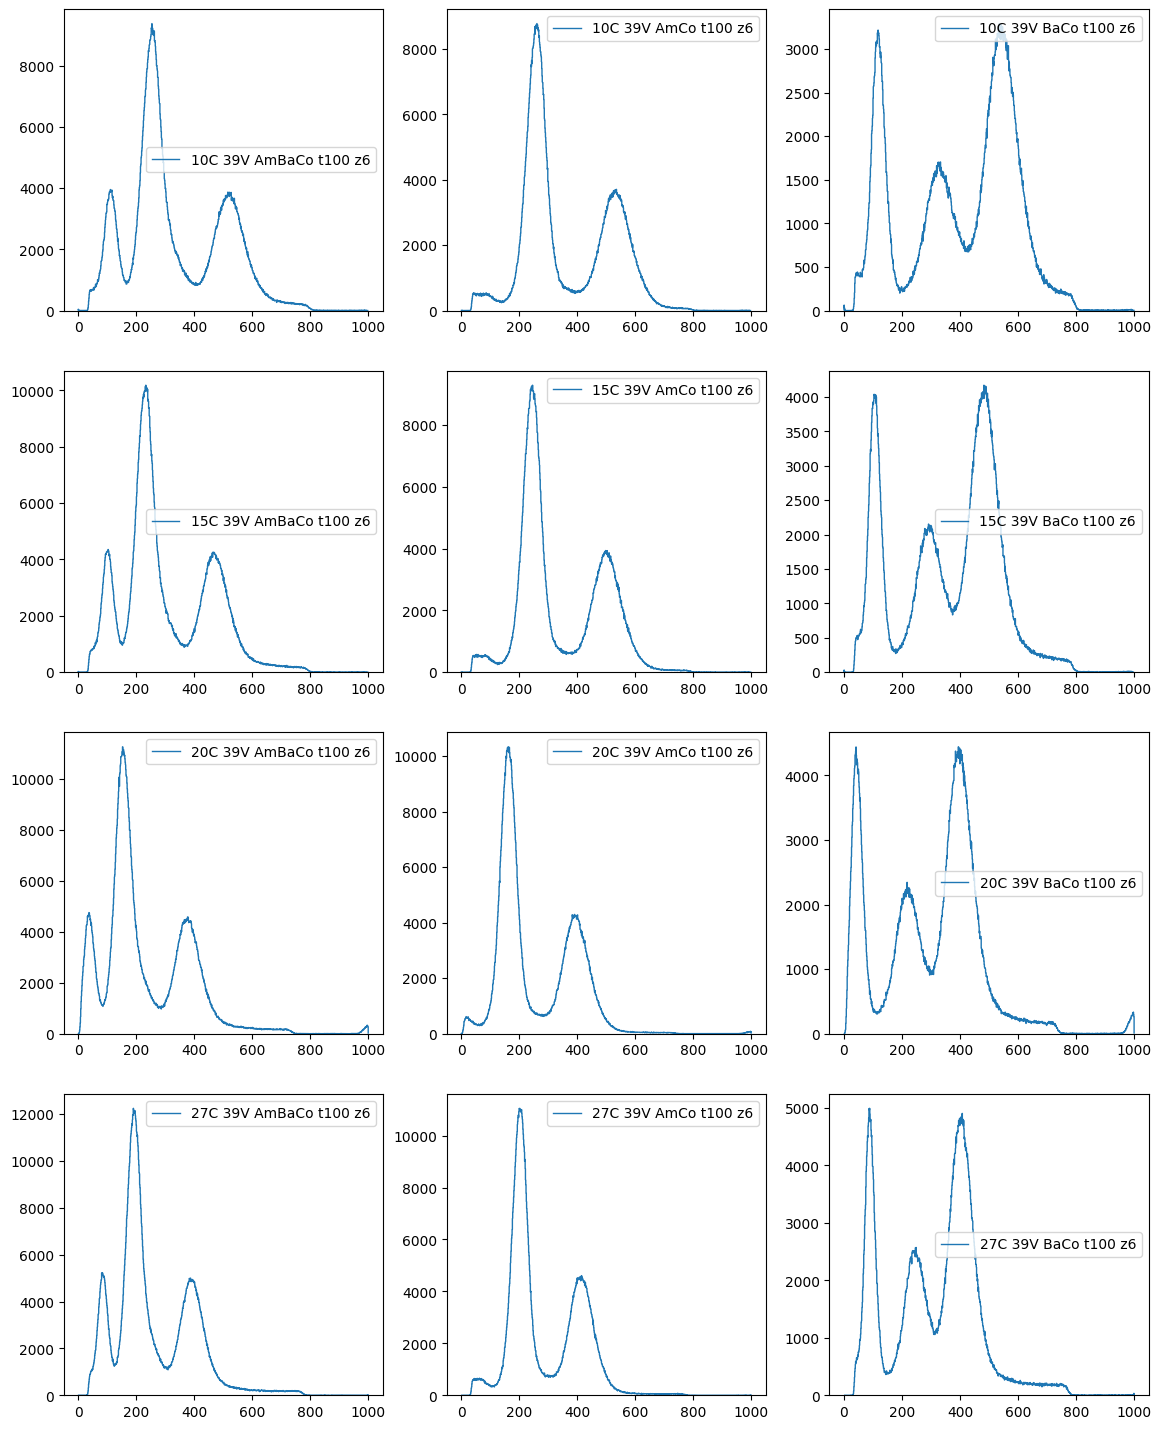

In [67]:
fig, ax = plt.subplots(4,3, figsize=(14,18))
bins = np.arange(1001)

for i, axis in enumerate(ax.flatten()):

    summation = spectra_types_1[i].sum(axis=0)[3]

    axis.stairs(summation, bins, label=f'{types[i]}')
    axis.legend()

### Actual Test: Low T

In [68]:
temp_gain_3 = Temp_gain / 'T_vary/T_vary_lowT'
spec_files = sorted(temp_gain_3.glob('*.bin'))
spec_files

[PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/-10C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/-10C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/-10C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/-5C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/-5C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/-5C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/0C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/0C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/0C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/5C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/5C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/T_vary/T_vary_lowT/5C_39V_BaCo_t1

In [69]:
PACKET_SIZE = 8000
types=['-10C 39V AmBaCo t100 z6', '-10C 39V AmCo t100 z6', '-10C 39V BaCo t100 z6', '-5C 39V AmBaCo t100 z6', '-5C 39V AmCo t100 z6', '-5C 39V BaCo t100 z6', '0C 39V AmBaCo t100 z6', '0C 39V AmCo t100 z6', '0C 39V BaCo t100 z6', '5C 39V AmBaCo t100 z6', '5C 39V AmCo t100 z6', '5C 39V BaCo t100 z6', '27C 39V AmBaCo t100 z6', '27C 39V AmCo t100 z6', '27C 39V BaCo t100 z6', '27C 39V BaCo2 t100 z6', '27C 39V BaCo3 t100 z6', '27C 39V BaCo t100 z6', '27C 39V Ba t100 z6', '27C 39V Co57 t100 z6']
spectra_types_2 = []

for fn in spec_files:
    spectra = spec_parse(fn, PACKET_SIZE)
    spectra_types_2.append(spectra)

print(spectra.shape)
print('There are spectra for', len(spectra_types_2), 'spectra types')

(1920, 4, 1000)
There are spectra for 12 spectra types


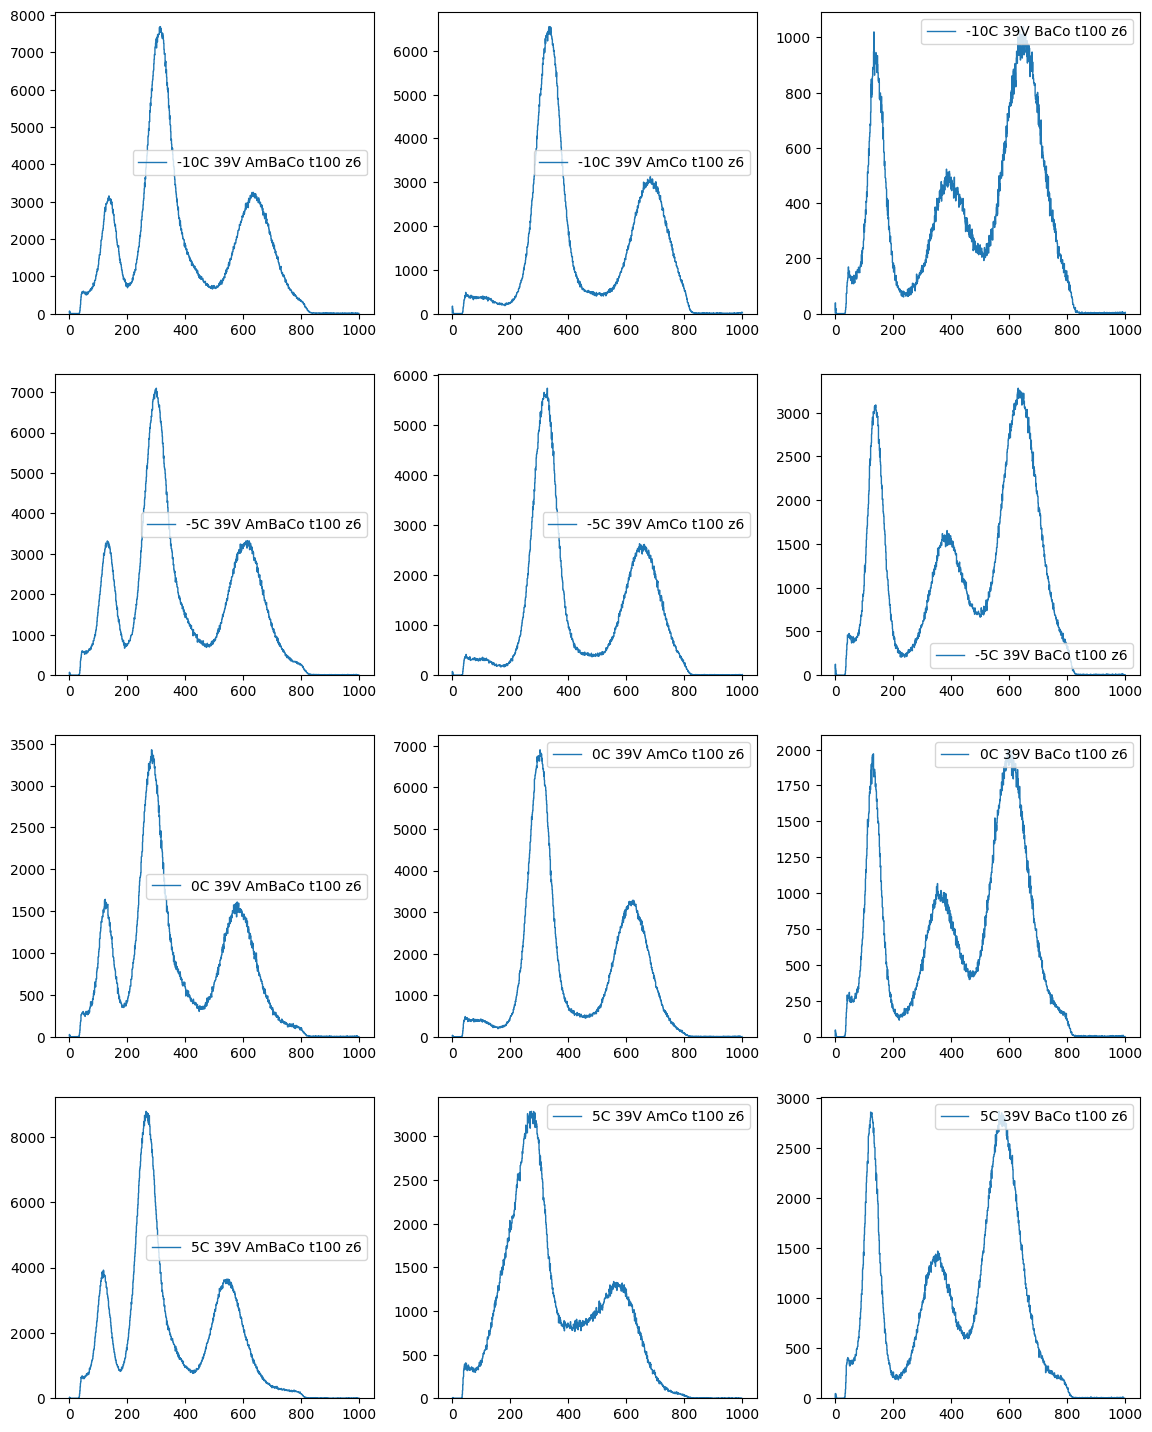

In [70]:
fig, ax = plt.subplots(4,3, figsize=(14,18))
bins = np.arange(1001)
for i, axis in enumerate(ax.flatten()):
    summation = spectra_types_2[i].sum(axis=0)[3]

    axis.stairs(summation, bins, label=f'{types[i]}')
    axis.legend()

### Peaks fitting

In [71]:
spectra_types_1_T = [10, 15, 20, 27]
spectra_types_2_T = [-10, -5, 0, 5]
Temps = spectra_types_2_T + spectra_types_1_T
Temps

[-10, -5, 0, 5, 10, 15, 20, 27]

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_240334/1884531101.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
/tmp/ipykernel_240334/1884531101.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='gray', linestyle='dashed')


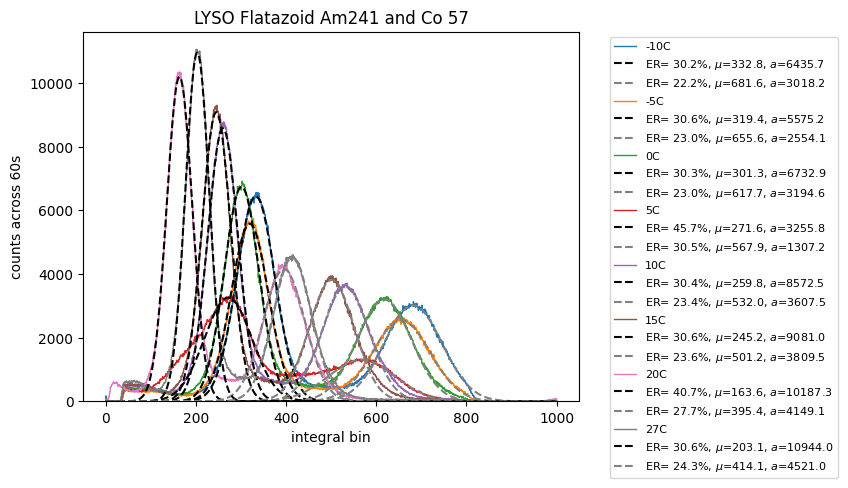

In [72]:
bins = np.arange(1001)
range_ = [[240, 400], [220, 400], [230, 380], [240, 350], [200, 340], [180, 320], [100, 220], [140, 250]] # 60 keV peak
range2 = [[580, 790], [570, 780], [520, 650], [520, 700], [450, 610], [425, 580], [320, 500], [350, 500]] # 122 keV peak
ch_spectra = [spectra_types_2[1], spectra_types_2[4], spectra_types_2[7], spectra_types_2[10], spectra_types_1[1], spectra_types_1[4], spectra_types_1[7], spectra_types_1[10]]
mu_ = [330, 319, 300, 270, 260, 245, 160, 200, 280, 280]
mu_2 = [680, 655, 620, 560, 530, 500, 395, 410, 280, 280]
amp = [37000, 40000, 42000, 43000, 37000, 40000, 42000, 43000, 42000, 42000]
w_ = [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
label = ['-10C', '-5C', '0C', '5C', '10C', '15C', '20C', '27C']

fig, ax = plt.subplots()

for i in np.arange(8):
    mids = bins[:-1] + np.diff(bins)/2
    rangee = (mids >= range_[i][0]) & (mids <= range_[i][1])
    rang22 = (mids >= range2[i][0]) & (mids <= range2[i][1])
    spectra = np.array(ch_spectra[i])
    summation = spectra.sum(axis=0)[3]


    po, pc = sco.curve_fit(gauss, mids[rangee], summation[rangee], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po2, pc2 = sco.curve_fit(gauss, mids[rang22], summation[rang22], p0=[mu_2[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    mu2, a2, w2 = po2
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    fwhm2 = np.abs((2 * np.sqrt(np.log(2)) * w2 / mu2) * 100)

    ax.stairs(summation, bins, label=label[i])
    ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='gray', linestyle='dashed')
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*60) // 32}s', title='LYSO Flatazoid Am241 and Co 57')
# ax.set_xlim(100,500)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [73]:
peaks_60keV = [332.8, 319.4, 301.3, 271.6, 259.8, 245.2, 163.6, 203.1]
ER_60keV = [30.2, 30.6, 30.3, 45.7, 30.4, 30.6, 40.7, 30.6]
peaks_122keV = [681.6, 655.6, 617.7, 567.9, 532, 501.2, 395.4, 414.1]
ER_122keV = [22.2, 23.0, 23.0, 30.5, 23.4, 23.6, 27.7, 24.3]

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_240334/931929474.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
/tmp/ipykernel_240334/931929474.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='red', linestyle='dashed')
/tmp/ipykernel_240334/931929474.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')


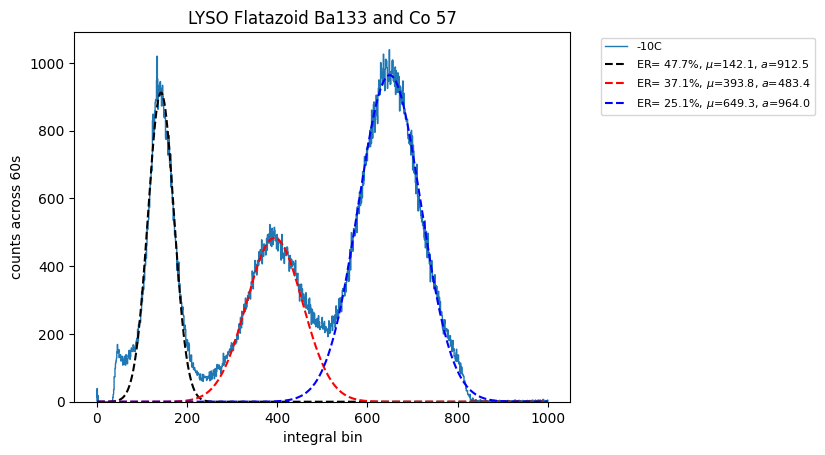

In [74]:
bins = np.arange(1001)
range_ = [[100, 200], [80, 190], [80, 180], [70, 170], [80, 180], [80, 170], [0, 100], [60, 140]] # 30 keV peak
range2 = [[300, 440], [280, 440], [260, 420], [280, 390], [220, 390], [220, 360], [130, 260], [180, 290]] # 80 keV peak
range3 = [[520, 780], [540, 660], [510, 710], [470, 680], [430, 660], [400, 580], [320, 480], [350, 480]] # 122 keV peak
ch_spectra = [spectra_types_2[2], spectra_types_2[5], spectra_types_2[8], spectra_types_2[11],spectra_types_1[2], spectra_types_1[5], spectra_types_1[8], spectra_types_1[11]]
mu_ = [140, 140, 132, 126, 120, 110, 45, 90, 280, 280]
mu_2 = [400, 390, 365, 350, 330, 300, 220, 250, 280, 280]
mu_3 = [640, 640, 600, 576, 544, 480, 395, 400, 280, 280]
amp = [37000, 40000, 37000, 40000, 42000, 43000, 42000, 42000]
w_ = [10, 10, 10, 10, 10, 10, 10, 10]
label = ['-10C', '-5C', '0C', '5C', '10C', '15C', '20C', '27C']
# label = ['-10C', '-5C', '0C', '5C']

fig, ax = plt.subplots()

for i in np.arange(1):
    mids = bins[:-1] + np.diff(bins)/2
    rangee = (mids >= range_[i][0]) & (mids <= range_[i][1])
    rang22 = (mids >= range2[i][0]) & (mids <= range2[i][1])
    rang33 = (mids >= range3[i][0]) & (mids <= range3[i][1])
    spectra = np.array(ch_spectra[i])
    summation = spectra.sum(axis=0)[3]


    po, pc = sco.curve_fit(gauss, mids[rangee], summation[rangee], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po2, pc2 = sco.curve_fit(gauss, mids[rang22], summation[rang22], p0=[mu_2[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po3, pc3 = sco.curve_fit(gauss, mids[rang33], summation[rang33], p0=[mu_3[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    mu2, a2, w2 = po2
    mu3, a3, w3 = po3
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    fwhm2 = np.abs((2 * np.sqrt(np.log(2)) * w2 / mu2) * 100)
    fwhm3 = np.abs((2 * np.sqrt(np.log(2)) * w3 / mu3) * 100)

    ax.stairs(summation, bins, label=label[i])
    ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='red', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*60) // 32}s', title='LYSO Flatazoid Ba133 and Co 57')
# ax.set_xlim(100,500)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [75]:
peaks_30keV = [142.1, 139.1, 131.3, 125.6, 118.8, 106.3, 44.9, 89.4]
ER_30keV = [47.7, 47.9, 48.0, 47.6, 49.3, 50.2, 104.4, 49.0]
peaks_81keV = [393.8, 385.9, 364.6, 349.2, 330.2, 295.6, 220.5, 246.4]
ER_81keV = [37.1, 37.4, 37.8, 37.1, 38.8, 38.8, 47.8, 37.9]
peaks_122keV_2 = [649.3, 636.5, 602.2, 576.6, 543.9, 483.3, 398.2, 403.8]
ER_122keV_2 = [25.1, 23.6, 24.9, 24.9, 25.3, 24.8, 28.0, 24.9]

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_240334/1524951348.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
/tmp/ipykernel_240334/1524951348.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')


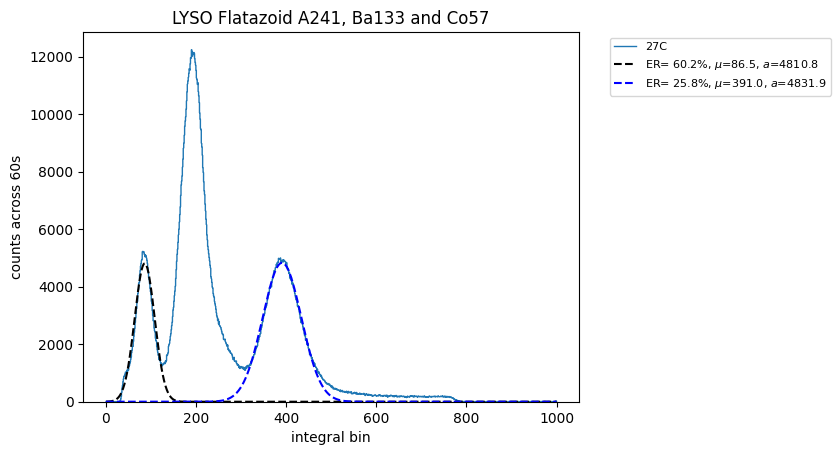

In [76]:
bins = np.arange(1001)
range_ = [[100, 200], [80, 190], [80, 180], [70, 170], [80, 180], [80, 170], [0, 100], [60, 140]] # 30 keV peak
range2 = [[300, 440], [280, 440], [260, 420], [280, 390], [220, 390], [220, 360], [130, 260], [180, 290]] # 80 keV peak
range3 = [[520, 780], [540, 660], [510, 710], [470, 680], [430, 660], [400, 580], [320, 480], [350, 480]] # 122 keV peak
ch_spectra = [spectra_types_2[0], spectra_types_2[3], spectra_types_2[6], spectra_types_2[9],spectra_types_1[0], spectra_types_1[3], spectra_types_1[6], spectra_types_1[9]]
mu_ = [140, 140, 132, 126, 120, 110, 45, 90, 280, 280]
mu_2 = [400, 390, 365, 350, 330, 300, 220, 250, 280, 280]
mu_3 = [640, 640, 600, 576, 544, 480, 395, 400, 280, 280]
amp = [37000, 40000, 37000, 40000, 42000, 43000, 42000, 42000]
w_ = [10, 10, 10, 10, 10, 10, 10, 10]
label = ['-10C', '-5C', '0C', '5C', '10C', '15C', '20C', '27C']
# label = ['-10C', '-5C', '0C', '5C']

fig, ax = plt.subplots()

for i in np.arange(7,8):
    mids = bins[:-1] + np.diff(bins)/2
    rangee = (mids >= range_[i][0]) & (mids <= range_[i][1])
    # rang22 = (mids >= range2[i][0]) & (mids <= range2[i][1])
    rang33 = (mids >= range3[i][0]) & (mids <= range3[i][1])
    spectra = np.array(ch_spectra[i])
    summation = spectra.sum(axis=0)[3]


    po, pc = sco.curve_fit(gauss, mids[rangee], summation[rangee], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    # po2, pc2 = sco.curve_fit(gauss, mids[rang22], summation[rang22], p0=[mu_2[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po3, pc3 = sco.curve_fit(gauss, mids[rang33], summation[rang33], p0=[mu_3[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    mu2, a2, w2 = po2
    mu3, a3, w3 = po3
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    fwhm2 = np.abs((2 * np.sqrt(np.log(2)) * w2 / mu2) * 100)
    fwhm3 = np.abs((2 * np.sqrt(np.log(2)) * w3 / mu3) * 100)

    ax.stairs(summation, bins, label=label[i])
    ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    # ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='red', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*60) // 32}s', title='LYSO Flatazoid A241, Ba133 and Co57')
# ax.set_xlim(100,500)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [77]:
peaks_30keV_2 = [138.1, 132.5, 126.2, 118.5, 113.3, 100.7, 41.0, 86.5]
ER_30keV_2 = [53.2, 51.6, 52.1, 52.1, 57.6, 69.4, 121.3, 60.2]
peaks_122keV_3 = [636.8, 608.1, 581.7, 545.0, 520.9, 471.2, 377.5, 391.0]
ER_122keV_3 = [24.9, 23.7, 25.6, 25.6, 28.0, 25.6, 25.2, 29.2, 25.8]

Same as above but using the fits from AmCo combination

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_240334/3346738655.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')


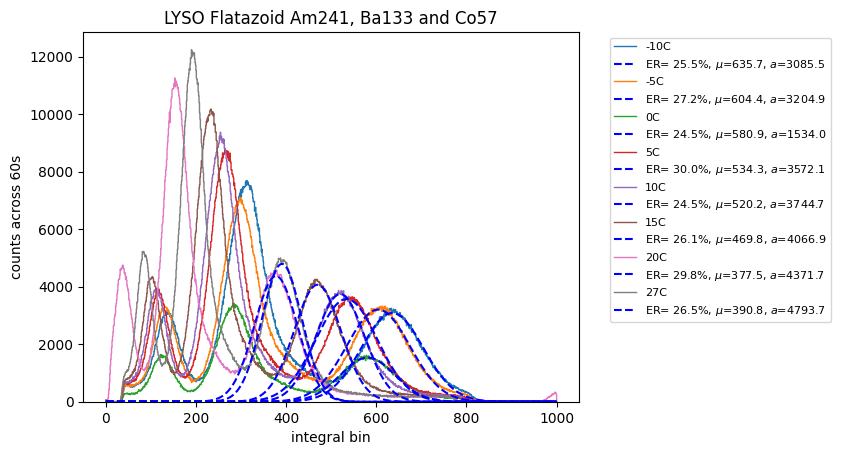

In [78]:
bins = np.arange(1001)
range_ = [[240, 400], [220, 400], [230, 380], [240, 350], [200, 340], [180, 320], [100, 220], [140, 250]] # 60 keV peak
range3 = [[580, 790], [570, 780], [520, 650], [520, 700], [450, 610], [425, 580], [320, 500], [350, 500]] # 122 keV peak
ch_spectra = [spectra_types_2[0], spectra_types_2[3], spectra_types_2[6], spectra_types_2[9],spectra_types_1[0], spectra_types_1[3], spectra_types_1[6], spectra_types_1[9]]
mu_ = [140, 140, 132, 126, 120, 110, 45, 90, 280, 280]
mu_2 = [400, 390, 365, 350, 330, 300, 220, 250, 280, 280]
mu_3 = [640, 640, 600, 576, 544, 480, 395, 400, 280, 280]
amp = [37000, 40000, 37000, 40000, 42000, 43000, 42000, 42000]
w_ = [10, 10, 10, 10, 10, 10, 10, 10]
label = ['-10C', '-5C', '0C', '5C', '10C', '15C', '20C', '27C']
# label = ['-10C', '-5C', '0C', '5C']

fig, ax = plt.subplots()

for i in np.arange(8):
    mids = bins[:-1] + np.diff(bins)/2
    rangee = (mids >= range_[i][0]) & (mids <= range_[i][1])
    # rang22 = (mids >= range2[i][0]) & (mids <= range2[i][1])
    rang33 = (mids >= range3[i][0]) & (mids <= range3[i][1])
    spectra = np.array(ch_spectra[i])
    summation = spectra.sum(axis=0)[3]


    # po, pc = sco.curve_fit(gauss, mids[rangee], summation[rangee], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    # po2, pc2 = sco.curve_fit(gauss, mids[rang22], summation[rang22], p0=[mu_2[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po3, pc3 = sco.curve_fit(gauss, mids[rang33], summation[rang33], p0=[mu_3[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    mu2, a2, w2 = po2
    mu3, a3, w3 = po3
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    fwhm2 = np.abs((2 * np.sqrt(np.log(2)) * w2 / mu2) * 100)
    fwhm3 = np.abs((2 * np.sqrt(np.log(2)) * w3 / mu3) * 100)

    ax.stairs(summation, bins, label=label[i])
    # ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    # ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='red', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*60) // 32}s', title='LYSO Flatazoid Am241, Ba133 and Co57')
# ax.set_xlim(100,500)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [79]:
peaks_122keV_4 = [635.7, 604.4, 580.9, 534.3, 520.2, 469.8, 377.5, 390.8]
ER_122keV_4 = [25.5, 27.2, 24.5, 30.0, 24.5, 30.0, 24.5, 26.1, 29.8, 26.5]

### Summary plots

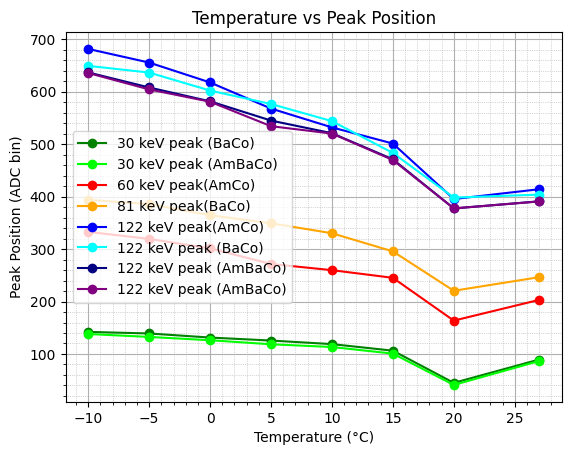

In [80]:
plt.plot(Temps, peaks_30keV, label='30 keV peak (BaCo)', color='green', marker='o')
plt.plot(Temps, peaks_30keV_2, label='30 keV peak (AmBaCo)', color='lime', marker='o')
plt.plot(Temps, peaks_60keV, label='60 keV peak(AmCo)', color='red', marker='o')
plt.plot(Temps, peaks_81keV, label='81 keV peak(BaCo)', color='orange', marker='o')
plt.plot(Temps, peaks_122keV, label='122 keV peak(AmCo)', color='blue', marker='o')
plt.plot(Temps, peaks_122keV_2, label='122 keV peak (BaCo)', color='cyan', marker='o')
plt.plot(Temps, peaks_122keV_3, label='122 keV peak (AmBaCo)', color='navy', marker='o')
plt.plot(Temps, peaks_122keV_4, label='122 keV peak (AmBaCo)', color='purple', marker='o') # using AmCo fit parameters
plt.xlabel('Temperature (°C)')
plt.ylabel('Peak Position (ADC bin)')
plt.title('Temperature vs Peak Position')
plt.minorticks_on()
plt.grid(which='both')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.legend()
plt.show()

percentage gain change

In [81]:
percentage_increase_30keV = [((p - peaks_30keV[-1])/peaks_30keV[-1]) * 100 for p in peaks_30keV]
percentage_increase_60keV = [((p - peaks_60keV[-1])/peaks_60keV[-1]) * 100 for p in peaks_60keV]
percentage_increase_81keV = [((p - peaks_81keV[-1])/peaks_81keV[-1]) * 100 for p in peaks_81keV]
percentage_increase_122keV = [((p - peaks_122keV[-1])/peaks_122keV[-1]) * 100 for p in peaks_122keV]
percentage_increase_122keV_2 = [((p - peaks_122keV_2[-1])/peaks_122keV_2[-1]) * 100 for p in peaks_122keV_2]

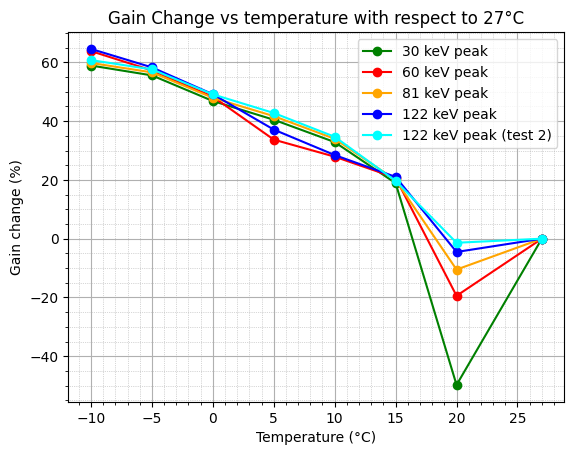

In [82]:
plt.plot(Temps, percentage_increase_30keV, label='30 keV peak', color='green', marker='o')
plt.plot(Temps, percentage_increase_60keV, label='60 keV peak', color='red', marker='o')
plt.plot(Temps, percentage_increase_81keV, label='81 keV peak', color='orange', marker='o')
plt.plot(Temps, percentage_increase_122keV, label='122 keV peak', color='blue', marker='o')
plt.plot(Temps, percentage_increase_122keV_2, label='122 keV peak (test 2)', color='cyan', marker='o')
plt.xlabel('Temperature (°C)')
plt.ylabel('Gain change (%)')
plt.title('Gain Change vs temperature with respect to 27°C')
plt.minorticks_on()
plt.grid(which='both')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.legend()
plt.show()

In [83]:
p_inc_30keV = np.diff([p/5 for p in percentage_increase_30keV])
print('mean of 30 keV peak increase difference', np.mean(p_inc_30keV))
p_inc_60keV = np.diff([p/5 for p in percentage_increase_60keV])
print('mean of 60 keV peak increase difference', np.mean(p_inc_60keV))
p_inc_81keV = np.diff([p/5 for p in percentage_increase_81keV])
print('mean of 81 keV peak increase difference', np.mean(p_inc_81keV))
p_inc_122keV = np.diff([p/5 for p in percentage_increase_122keV])
print('mean of 122 keV peak increase difference', np.mean(p_inc_122keV))
p_inc_122keV_2 = np.diff([p/5 for p in percentage_increase_122keV_2])
print('mean of 122 keV peak increase difference (test 2)', np.mean(p_inc_122keV_2))

mean of 30 keV peak increase difference -1.6842441674656432
mean of 60 keV peak increase difference -1.8245762115776891
mean of 81 keV peak increase difference -1.709183673469388
mean of 122 keV peak increase difference -1.8456549487701384
mean of 122 keV peak increase difference (test 2) -1.7370692705016622


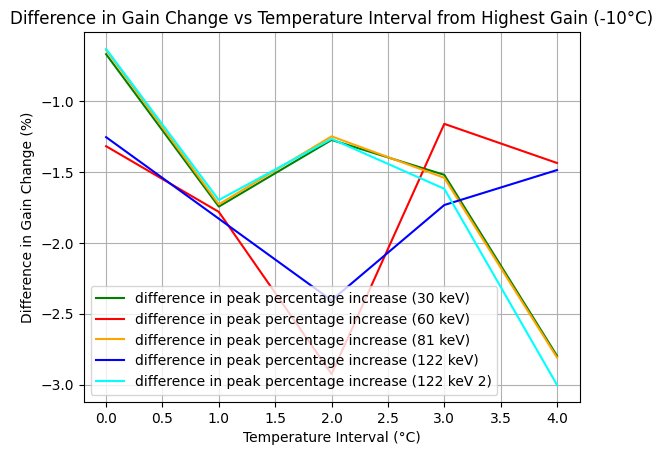

In [84]:
plt.plot(p_inc_30keV[:-2], color='green', label='difference in peak percentage increase (30 keV)')
plt.plot(p_inc_60keV[:-2], color='red', label='difference in peak percentage increase (60 keV)')
plt.plot(p_inc_81keV[:-2], color='orange', label='difference in peak percentage increase (81 keV)')
plt.plot(p_inc_122keV[:-2], color='blue', label='difference in peak percentage increase (122 keV)')
plt.plot(p_inc_122keV_2[:-2], color='cyan', label='difference in peak percentage increase (122 keV 2)')
plt.xlabel('Temperature Interval (°C)')
plt.ylabel('Difference in Gain Change (%)')
plt.title('Difference in Gain Change vs Temperature Interval from Highest Gain (-10°C)')
plt.grid()
plt.legend()
plt.show()

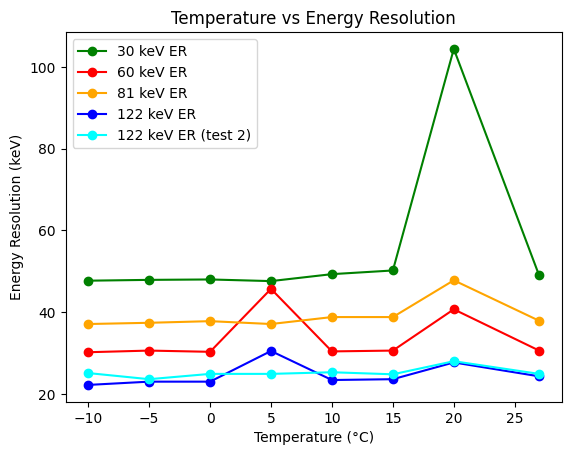

In [85]:
plt.plot(Temps, ER_30keV, label='30 keV ER', color='green', marker='o')
plt.plot(Temps, ER_60keV, label='60 keV ER', color='red', marker='o')
plt.plot(Temps, ER_81keV, label='81 keV ER', color='orange', marker='o')
plt.plot(Temps, ER_122keV, label='122 keV ER', color='blue', marker='o')
plt.plot(Temps, ER_122keV_2, label='122 keV ER (test 2)', color='cyan', marker='o')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Resolution (keV)')
plt.title('Temperature vs Energy Resolution')
plt.legend()
plt.show()

Peak trends was consistent for all the temperatures except at 20C, but 5C had a weird spectra for Co and Am

### Retest at higher temperature - due to the peak dip at 20C

In [86]:
temp_gain_4 = Temp_gain / 'highT_vary_retest'
spec_files = sorted(temp_gain_4.glob('*.bin'))
spec_files

[PosixPath('calibration/T_gain_curve/highT_vary_retest/11C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/11C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/11C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/14C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/14C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/14C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/17C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/17C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/17C_39V_BaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/20C_39V_AmBaCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/20C_39V_AmCo_t100_z6.bin'),
 PosixPath('calibration/T_gain_curve/highT_vary_retest/20C_39V_BaCo_t100_z6.bin

In [87]:
PACKET_SIZE = 8000
types=['11C 39V AmBaCo t100 z6', '11C 39V AmCo t100 z6', '11C 39V BaCo t100 z6', '14C 39V AmBaCo t100 z6', '14C 39V AmCo t100 z6', '14C 39V BaCo t100 z6', '17C 39V AmBaCo t100 z6', '17C 39V AmCo t100 z6', '17C 39V BaCo t100 z6', '20C 39V AmBaCo t100 z6', '20C 39V AmCo t100 z6', '20C 39V BaCo t100 z6', '23C 39V AmBaCo t100 z6', '23C 39V AmCo t100 z6', '23C 39V BaCo t100 z6', '26C 39V AmBaCo t100 z6', '26C 39V AmCo t100 z6', '26C 39V BaCo t100 z6', '27C 39V BaCo t100 z6', '27C 39V Ba t100 z6', '27C 39V Co57 t100 z6']
spectra_types_3 = []

for fn in spec_files:
    spectra = spec_parse(fn, PACKET_SIZE)
    spectra_types_3.append(spectra)

print(spectra.shape)
print('There are spectra for', len(spectra_types_3), 'spectra types')

(1920, 4, 1000)
There are spectra for 18 spectra types


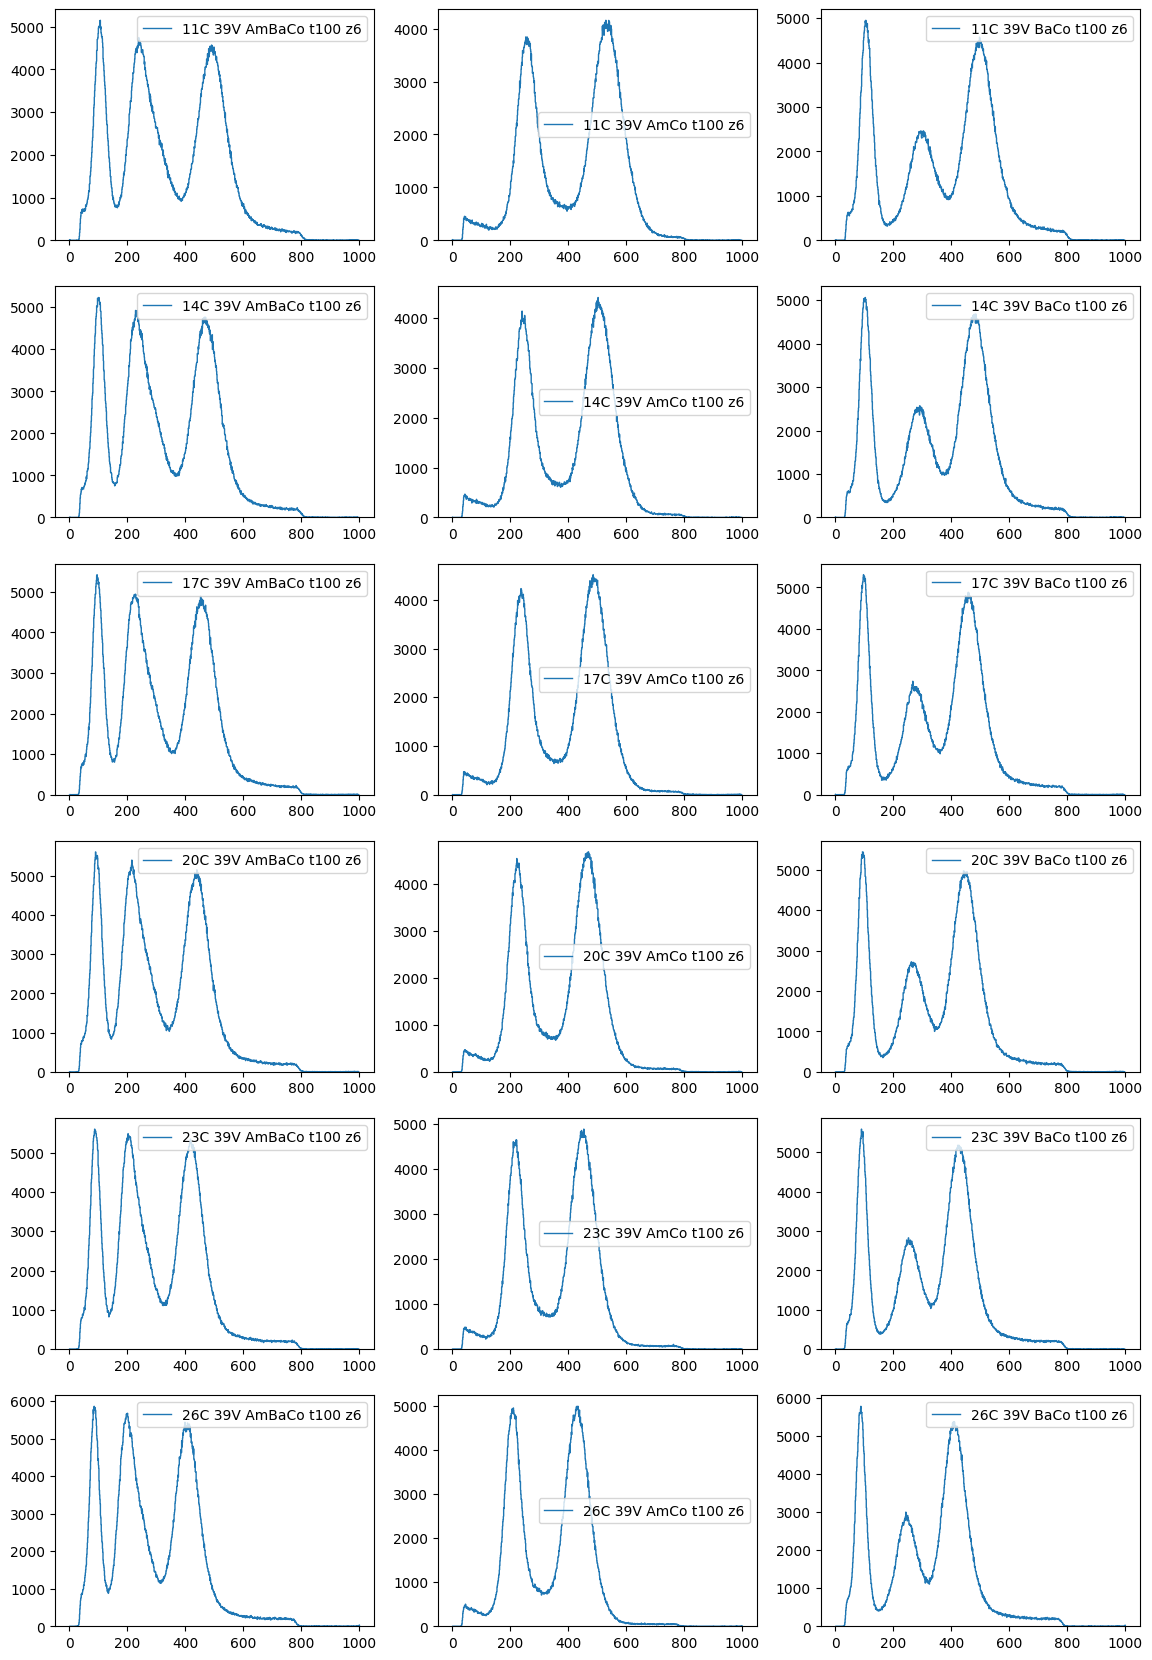

In [88]:
fig, ax = plt.subplots(6,3, figsize=(14,21))

for i, axis in enumerate(ax.flatten()):
    summation = spectra_types_3[i].sum(axis=0)[3]

    axis.stairs(summation, bins, label=f'{types[i]}')
    axis.legend()

### Spectra fitting

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_240334/1080691476.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
/tmp/ipykernel_240334/1080691476.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='grey', linestyle='dashed')


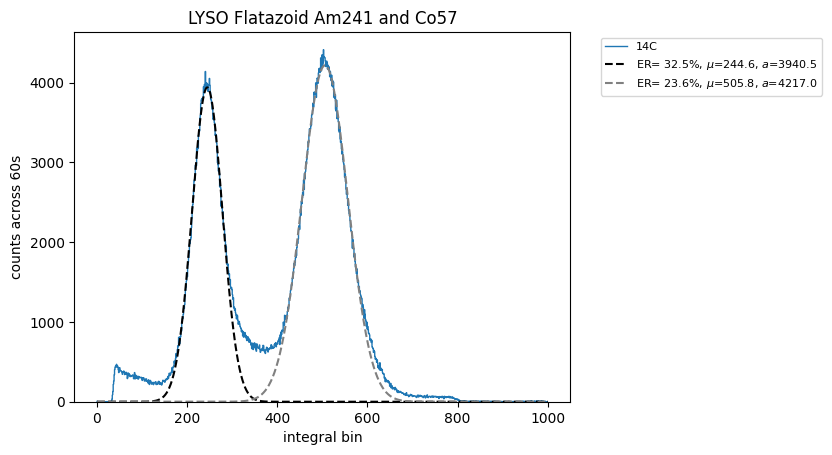

In [89]:
bins = np.arange(1001)
range_ = [[180, 320], [160, 290], [160, 290], [150, 290], [100, 280], [120, 260]] # 60 keV peak
range2 = [[420, 640], [420, 600], [400, 580], [370, 560], [360, 560], [360, 550]] # 122 keV peak
ch_spectra = [spectra_types_3[1], spectra_types_3[4], spectra_types_3[7], spectra_types_3[10], spectra_types_3[13], spectra_types_3[16]]
mu_ = [250, 240, 260, 227, 209, 218]
mu_2 = [530, 500, 530, 466, 430, 450]
amp = [42000, 43000, 37000, 40000, 42000, 43000]
w_ = [10, 10, 10, 10, 10, 10]
label = ['11C', '14C', '17C', '20C', '23C', '26C']

fig, ax = plt.subplots()

for i in np.arange(1,2):
    mids = bins[:-1] + np.diff(bins)/2
    rangee = (mids >= range_[i][0]) & (mids <= range_[i][1])
    rang22 = (mids >= range2[i][0]) & (mids <= range2[i][1])
    spectra = np.array(ch_spectra[i])
    summation = spectra.sum(axis=0)[3]


    po, pc = sco.curve_fit(gauss, mids[rangee], summation[rangee], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po2, pc2 = sco.curve_fit(gauss, mids[rang22], summation[rang22], p0=[mu_2[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    mu2, a2, w2 = po2
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    fwhm2 = np.abs((2 * np.sqrt(np.log(2)) * w2 / mu2) * 100)

    ax.stairs(summation, bins, label=label[i])
    ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='grey', linestyle='dashed')
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*60) // 32}s', title='LYSO Flatazoid Am241 and Co57')
# ax.set_xlim(100,500)
# ax.grid()
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [90]:
spectra_temps = [11, 14, 17, 20, 23, 26]

In [91]:
peaks_60keV_ = [258.7, 244.6, 237.5, 226.5, 218.6, 209.4]
ER_60keV_ = [33.2, 32.5, 33.2, 34.2, 34.6, 33.5]
peaks_122keV_ = [533.8, 505.8, 488.7, 466.4, 450.5, 430.7]
ER_122keV_ = [24.0, 23.6, 23.8, 24.0, 24.3, 24.2]

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_240334/1691834604.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
/tmp/ipykernel_240334/1691834604.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='red', linestyle='dashed')
/tmp/ipykernel_240334/1691834604.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')


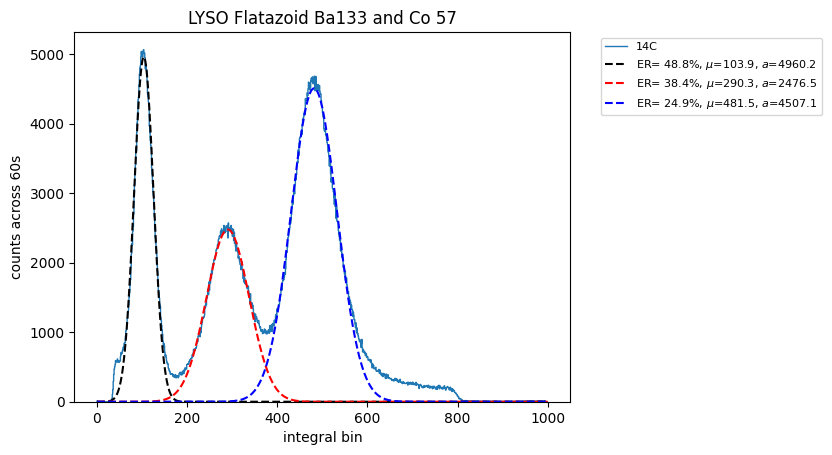

In [92]:
bins = np.arange(1001)
range_ = [[70, 170], [60, 150], [60, 140], [60, 140], [50, 150], [60, 140]] # 30 keV peak
range2 = [[210, 370], [200, 350], [190, 340], [190, 340], [190, 300], [180, 280]] # 80 keV peak
range3 = [[400, 590], [390, 580], [380, 560], [370, 540], [370, 520], [340, 480]] # 122 keV peak
ch_spectra = [spectra_types_3[2], spectra_types_3[5],spectra_types_3[8], spectra_types_3[11], spectra_types_3[14], spectra_types_3[17]]
mu_ = [107, 104, 99, 99, 97, 90]
mu_2 = [280, 290, 280, 280, 270, 250]
mu_3 = [490, 480, 460, 460, 450, 411]
amp = [37000, 40000, 42000, 43000, 42000, 42000]
w_ = [10, 10, 10, 10, 10, 10]
label = ['11C', '14C', '17C', '20C', '23C', '26C']
# label = ['-10C', '-5C', '0C', '5C']

fig, ax = plt.subplots()

for i in np.arange(1,2):
    mids = bins[:-1] + np.diff(bins)/2
    rangee = (mids >= range_[i][0]) & (mids <= range_[i][1])
    rang22 = (mids >= range2[i][0]) & (mids <= range2[i][1])
    rang33 = (mids >= range3[i][0]) & (mids <= range3[i][1])
    spectra = np.array(ch_spectra[i])
    summation = spectra.sum(axis=0)[3]


    po, pc = sco.curve_fit(gauss, mids[rangee], summation[rangee], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po2, pc2 = sco.curve_fit(gauss, mids[rang22], summation[rang22], p0=[mu_2[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po3, pc3 = sco.curve_fit(gauss, mids[rang33], summation[rang33], p0=[mu_3[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    mu2, a2, w2 = po2
    mu3, a3, w3 = po3
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    fwhm2 = np.abs((2 * np.sqrt(np.log(2)) * w2 / mu2) * 100)
    fwhm3 = np.abs((2 * np.sqrt(np.log(2)) * w3 / mu3) * 100)

    ax.stairs(summation, bins, label=label[i])
    ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='red', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*60) // 32}s', title='LYSO Flatazoid Ba133 and Co 57')
# ax.set_xlim(100,500)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [93]:
peaks_30keV_ = [107.7, 103.9, 99.3, 96.6, 92.3, 88.5]
ER_30keV_ = [48.9, 48.8, 48.4, 49.8, 49.8, 49.7]
peaks_81keV_ = [300.8, 290.3, 277.7, 269.2, 257.0, 246.7]
ER_81keV_ = [38.6, 38.4, 38.7, 38.7, 37.2, 37.1]
peaks_122keV_2_ = [497.4, 481.5, 460.4, 448.2, 428.0, 411.0]
ER_122keV_2_ = [24.7, 24.9, 25.0, 24.6, 25.0, 24.5]

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_240334/40407617.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
/tmp/ipykernel_240334/40407617.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')


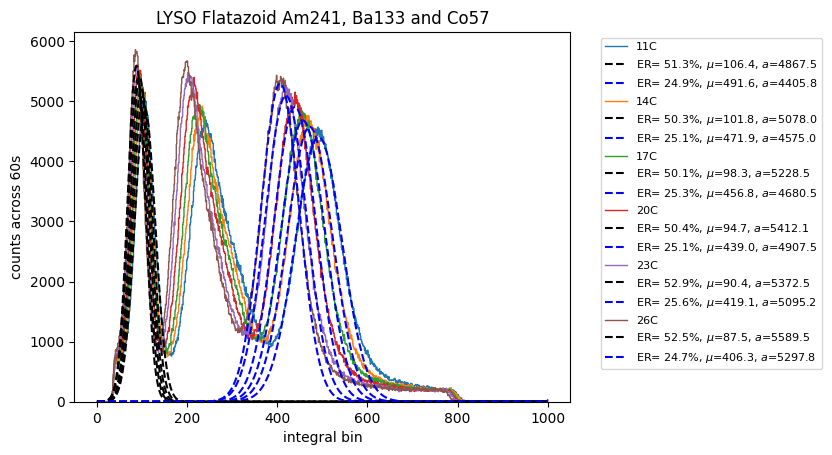

In [94]:
bins = np.arange(1001)
range_ = [[70, 170], [60, 150], [60, 140], [60, 140], [50, 150], [60, 140]] # 30 keV peak
range2 = [[210, 370], [200, 350], [190, 340], [190, 340], [190, 300], [180, 280]] # 80 keV peak
range3 = [[400, 590], [390, 580], [380, 560], [370, 540], [370, 520], [340, 480]] # 122 keV peak
ch_spectra = [spectra_types_3[0], spectra_types_3[3],spectra_types_3[6], spectra_types_3[9], spectra_types_3[12], spectra_types_3[15]]
mu_ = [107, 104, 99, 99, 97, 90]
mu_2 = [280, 290, 280, 280, 270, 250]
mu_3 = [490, 480, 460, 460, 450, 411]
amp = [37000, 40000, 42000, 43000, 42000, 42000]
w_ = [10, 10, 10, 10, 10, 10]
label = ['11C', '14C', '17C', '20C', '23C', '26C']
# label = ['-10C', '-5C', '0C', '5C']

fig, ax = plt.subplots()

for i in np.arange(6):
    mids = bins[:-1] + np.diff(bins)/2
    rangee = (mids >= range_[i][0]) & (mids <= range_[i][1])
    # rang22 = (mids >= range2[i][0]) & (mids <= range2[i][1])
    rang33 = (mids >= range3[i][0]) & (mids <= range3[i][1])
    spectra = np.array(ch_spectra[i])
    summation = spectra.sum(axis=0)[3]


    po, pc = sco.curve_fit(gauss, mids[rangee], summation[rangee], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    # po2, pc2 = sco.curve_fit(gauss, mids[rang22], summation[rang22], p0=[mu_2[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    po3, pc3 = sco.curve_fit(gauss, mids[rang33], summation[rang33], p0=[mu_3[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    mu2, a2, w2 = po2
    mu3, a3, w3 = po3
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    fwhm2 = np.abs((2 * np.sqrt(np.log(2)) * w2 / mu2) * 100)
    fwhm3 = np.abs((2 * np.sqrt(np.log(2)) * w3 / mu3) * 100)

    ax.stairs(summation, bins, label=label[i])
    ax.plot(mids, gauss(mids, *po), label=f'ER= {fwhm:.1f}%, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    # ax.plot(mids, gauss(mids, *po2), label=f'ER= {fwhm2:.1f}%, $\mu$={mu2:.1f}, $a$={a2:.1f}', color='red', linestyle='dashed')
    ax.plot(mids, gauss(mids, *po3), label=f'ER= {fwhm3:.1f}%, $\mu$={mu3:.1f}, $a$={a3:.1f}', color='blue', linestyle='dashed')
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*60) // 32}s', title='LYSO Flatazoid Am241, Ba133 and Co57')
# ax.set_xlim(100,500)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

In [95]:
peaks_30keV_2_ = [106.4, 101.8, 98.3, 94.7, 90.4, 87.5]
ER_30keV_2_ = [51.3, 50.3, 50.1, 50.4, 52.9, 52.5]
peaks_122keV_3_ = [491.6, 471.9, 456.8, 439.0, 419.1, 406.3]
ER_122keV_3_ = [24.9, 25.1, 25.3, 25.1, 25.6, 24.7]

### Comparison

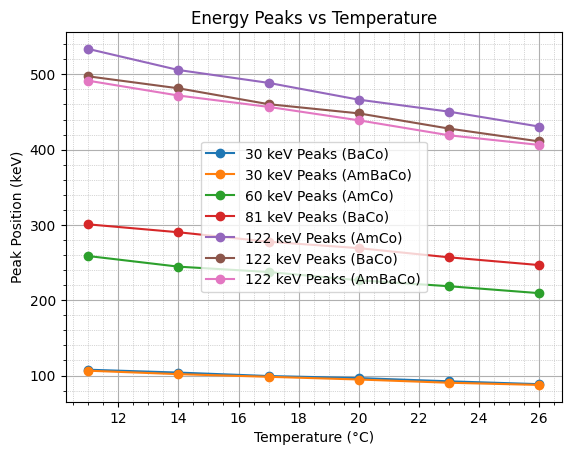

In [96]:
plt.plot(spectra_temps, peaks_30keV_, 'o-', label='30 keV Peaks (BaCo)')
plt.plot(spectra_temps, peaks_30keV_2_, 'o-', label='30 keV Peaks (AmBaCo)')
plt.plot(spectra_temps, peaks_60keV_, 'o-', label='60 keV Peaks (AmCo)')
plt.plot(spectra_temps, peaks_81keV_, 'o-', label='81 keV Peaks (BaCo)')
plt.plot(spectra_temps, peaks_122keV_, 'o-', label='122 keV Peaks (AmCo)')
plt.plot(spectra_temps, peaks_122keV_2_, 'o-', label='122 keV Peaks (BaCo)')
plt.plot(spectra_temps, peaks_122keV_3_, 'o-', label='122 keV Peaks (AmBaCo)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Peak Position (keV)')
plt.title('Energy Peaks vs Temperature')
plt.minorticks_on()
plt.grid(which='both')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.legend()
plt.show()

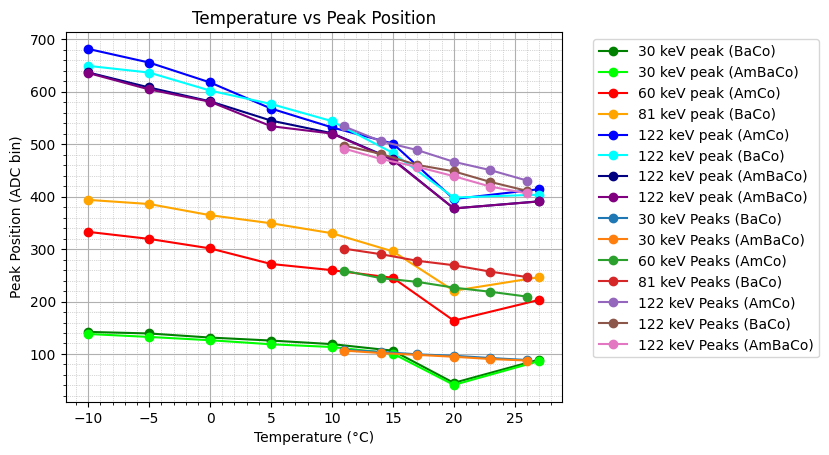

In [97]:
plt.plot(Temps, peaks_30keV, label='30 keV peak (BaCo)', color='green', marker='o')
plt.plot(Temps, peaks_30keV_2, label='30 keV peak (AmBaCo)', color='lime', marker='o')
plt.plot(Temps, peaks_60keV, label='60 keV peak (AmCo)', color='red', marker='o')
plt.plot(Temps, peaks_81keV, label='81 keV peak (BaCo)', color='orange', marker='o')
plt.plot(Temps, peaks_122keV, label='122 keV peak (AmCo)', color='blue', marker='o')
plt.plot(Temps, peaks_122keV_2, label='122 keV peak (BaCo)', color='cyan', marker='o')
plt.plot(Temps, peaks_122keV_3, label='122 keV peak (AmBaCo)', color='navy', marker='o')
plt.plot(Temps, peaks_122keV_4, label='122 keV peak (AmBaCo)', color='purple', marker='o')
plt.plot(spectra_temps, peaks_30keV_, 'o-', label='30 keV Peaks (BaCo)')
plt.plot(spectra_temps, peaks_30keV_2_, 'o-', label='30 keV Peaks (AmBaCo)')
plt.plot(spectra_temps, peaks_60keV_, 'o-', label='60 keV Peaks (AmCo)')
plt.plot(spectra_temps, peaks_81keV_, 'o-', label='81 keV Peaks (BaCo)')
plt.plot(spectra_temps, peaks_122keV_, 'o-', label='122 keV Peaks (AmCo)')
plt.plot(spectra_temps, peaks_122keV_2_, 'o-', label='122 keV Peaks (BaCo)')
plt.plot(spectra_temps, peaks_122keV_3_, 'o-', label='122 keV Peaks (AmBaCo)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Peak Position (ADC bin)')
plt.title('Temperature vs Peak Position')
plt.minorticks_on()
plt.grid(which='both')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

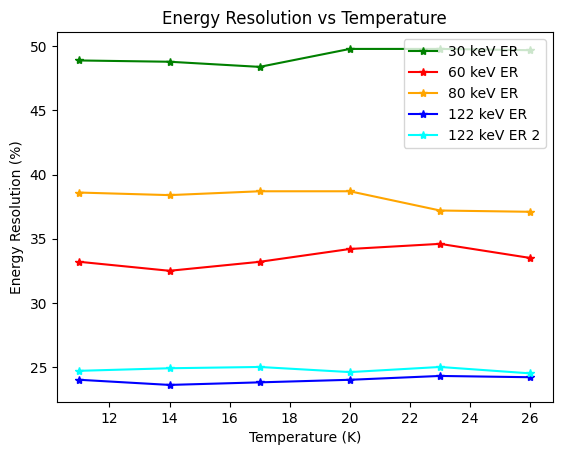

In [98]:
plt.plot(spectra_temps, ER_30keV_, label='30 keV ER', color='green', marker='*')
plt.plot(spectra_temps, ER_60keV_, label='60 keV ER', color='red', marker='*')
plt.plot(spectra_temps, ER_81keV_, label='80 keV ER', color='orange', marker='*')
plt.plot(spectra_temps, ER_122keV_, label='122 keV ER', color='blue', marker='*')
plt.plot(spectra_temps, ER_122keV_2_, label='122 keV ER 2', color='cyan', marker='*')
plt.xlabel('Temperature (K)')
plt.ylabel('Energy Resolution (%)')
plt.title('Energy Resolution vs Temperature')
plt.legend()
plt.show()

Percentage Gain Change

In [99]:
percentage_increase_30keV_ = [((p - peaks_30keV_[-1])/peaks_30keV_[-1]) * 100 for p in peaks_30keV_]
percentage_increase_60keV_ = [((p - peaks_60keV_[-1])/peaks_60keV_[-1]) * 100 for p in peaks_60keV_]
percentage_increase_81keV_ = [((p - peaks_81keV_[-1])/peaks_81keV_[-1]) * 100 for p in peaks_81keV_]
percentage_increase_122keV_ = [((p - peaks_122keV_[-1])/peaks_122keV_[-1]) * 100 for p in peaks_122keV_]
percentage_increase_122keV_2_ = [((p - peaks_122keV_2_[-1])/peaks_122keV_2_[-1]) * 100 for p in peaks_122keV_2_]

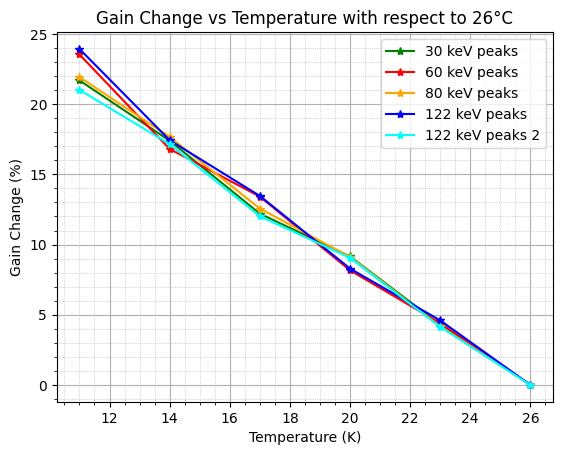

In [100]:
plt.plot(spectra_temps, percentage_increase_30keV_, label='30 keV peaks', color='green', marker='*')
plt.plot(spectra_temps, percentage_increase_60keV_, label='60 keV peaks', color='red', marker='*')
plt.plot(spectra_temps, percentage_increase_81keV_, label='80 keV peaks', color='orange', marker='*')
plt.plot(spectra_temps, percentage_increase_122keV_, label='122 keV peaks', color='blue', marker='*')
plt.plot(spectra_temps, percentage_increase_122keV_2_, label='122 keV peaks 2', color='cyan', marker='*')
plt.xlabel('Temperature (K)')
plt.ylabel('Gain Change (%)')
plt.title('Gain Change vs Temperature with respect to 26°C')
plt.minorticks_on()
plt.grid(which='both')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.legend()
plt.show()

In [101]:
p_inc_30keV_ = np.diff([p/3 for p in percentage_increase_30keV_])
print('mean of 30 keV peak increase difference', np.mean(p_inc_30keV_))
p_inc_60keV_ = np.diff([p/3 for p in percentage_increase_60keV_])
print('mean of 60 keV peak increase difference', np.mean(p_inc_60keV_))
p_inc_81keV_ = np.diff([p/3 for p in percentage_increase_81keV_])
print('mean of 81 keV peak increase difference', np.mean(p_inc_81keV_))
p_inc_122keV_ = np.diff([p/3 for p in percentage_increase_122keV_])
print('mean of 122 keV peak increase difference', np.mean(p_inc_122keV_))
p_inc_122keV_2_ = np.diff([p/3 for p in percentage_increase_122keV_2_])
print('mean of 122 keV peak increase difference (test 2)', np.mean(p_inc_122keV_2_))

mean of 30 keV peak increase difference -1.4463276836158194
mean of 60 keV peak increase difference -1.5695638331741477
mean of 81 keV peak increase difference -1.461964599378463
mean of 122 keV peak increase difference -1.5958517142636013
mean of 122 keV peak increase difference (test 2) -1.4014598540145982


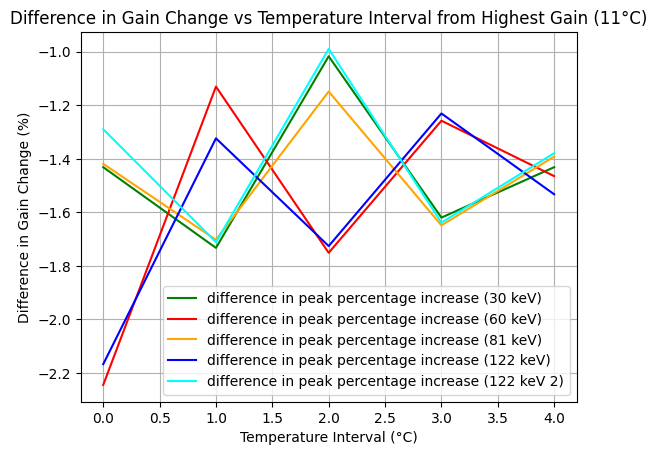

In [102]:
plt.plot(p_inc_30keV_, color='green', label='difference in peak percentage increase (30 keV)')
plt.plot(p_inc_60keV_, color='red', label='difference in peak percentage increase (60 keV)')
plt.plot(p_inc_81keV_, color='orange', label='difference in peak percentage increase (81 keV)')
plt.plot(p_inc_122keV_, color='blue', label='difference in peak percentage increase (122 keV)')
plt.plot(p_inc_122keV_2_, color='cyan', label='difference in peak percentage increase (122 keV 2)')
plt.xlabel('Temperature Interval (°C)')
plt.ylabel('Difference in Gain Change (%)')
plt.title('Difference in Gain Change vs Temperature Interval from Highest Gain (11°C)')
plt.grid()
plt.legend()
plt.show()

### Calibration curve fit as a function of temperature

In [103]:
peaks_30keV

[142.1, 139.1, 131.3, 125.6, 118.8, 106.3, 44.9, 89.4]

In [104]:
Temps

[-10, -5, 0, 5, 10, 15, 20, 27]

In [105]:
import pandas as pd

df = pd.DataFrame({
    'Peaks_30keV': peaks_30keV,
    'Peaks_60keV': peaks_60keV,
    'Peaks_81keV': peaks_81keV,
    'Peaks_122keV': peaks_122keV,
    'Peaks_122keV_2': peaks_122keV_2
}, index=Temps)
df

,Peaks_30keV,Peaks_60keV,Peaks_81keV,Peaks_122keV,Peaks_122keV_2
-10,142.1,332.8,393.8,681.6,649.3
-5,139.1,319.4,385.9,655.6,636.5
0,131.3,301.3,364.6,617.7,602.2
5,125.6,271.6,349.2,567.9,576.6
10,118.8,259.8,330.2,532.0,543.9
15,106.3,245.2,295.6,501.2,483.3
20,44.9,163.6,220.5,395.4,398.2
27,89.4,203.1,246.4,414.1,403.8


In [106]:
df_energy = pd.DataFrame({
    'ER_30keV': ER_30keV,
    'ER_60keV': ER_60keV,
    'ER_81keV': ER_81keV,
    'ER_122keV': ER_122keV,
    'ER_122keV_2': ER_122keV_2
}, index=Temps)
df_energy

,ER_30keV,ER_60keV,ER_81keV,ER_122keV,ER_122keV_2
-10,47.7,30.2,37.1,22.2,25.1
-5,47.9,30.6,37.4,23.0,23.6
0,48.0,30.3,37.8,23.0,24.9
5,47.6,45.7,37.1,30.5,24.9
10,49.3,30.4,38.8,23.4,25.3
15,50.2,30.6,38.8,23.6,24.8
20,104.4,40.7,47.8,27.7,28.0
27,49.0,30.6,37.9,24.3,24.9


In [107]:
df2 = pd.DataFrame({
    'Peaks_30keV': peaks_30keV_,
    'Peaks_60keV': peaks_60keV_,
    'Peaks_81keV': peaks_81keV_,
    'Peaks_122keV': peaks_122keV_,
    'Peaks_122keV_2': peaks_122keV_2_
}, index=spectra_temps)
df2

,Peaks_30keV,Peaks_60keV,Peaks_81keV,Peaks_122keV,Peaks_122keV_2
11,107.7,258.7,300.8,533.8,497.4
14,103.9,244.6,290.3,505.8,481.5
17,99.3,237.5,277.7,488.7,460.4
20,96.6,226.5,269.2,466.4,448.2
23,92.3,218.6,257.0,450.5,428.0
26,88.5,209.4,246.7,430.7,411.0


In [108]:
df2_energy = pd.DataFrame({
    'ER_30keV': ER_30keV_,
    'ER_60keV': ER_60keV_,
    'ER_81keV': ER_81keV_,
    'ER_122keV': ER_122keV_,
    'ER_122keV_2': ER_122keV_2_
}, index=spectra_temps)
df2_energy

,ER_30keV,ER_60keV,ER_81keV,ER_122keV,ER_122keV_2
11,48.9,33.2,38.6,24.0,24.7
14,48.8,32.5,38.4,23.6,24.9
17,48.4,33.2,38.7,23.8,25.0
20,49.8,34.2,38.7,24.0,24.6
23,49.8,34.6,37.2,24.3,25.0
26,49.7,33.5,37.1,24.2,24.5


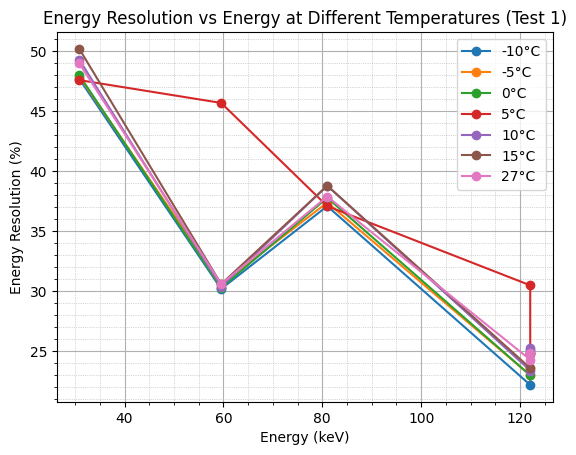

In [109]:
energies = [30.85, 59.54, 81, 122.06, 122.06]
plt.plot(energies, df_energy.loc[-10].values, 'o-', label='-10°C')
plt.plot(energies, df_energy.loc[-5].values, 'o-', label='-5°C')
plt.plot(energies, df_energy.loc[0].values, 'o-', label='0°C')
plt.plot(energies, df_energy.loc[5].values, 'o-', label='5°C')
plt.plot(energies, df_energy.loc[10].values, 'o-', label='10°C')
plt.plot(energies, df_energy.loc[15].values, 'o-', label='15°C')
plt.plot(energies, df_energy.loc[27].values, 'o-', label='27°C')
plt.xlabel('Energy (keV)')
plt.ylabel('Energy Resolution (%)')
plt.title('Energy Resolution vs Energy at Different Temperatures (Test 1)')
plt.minorticks_on()
plt.grid(which='both')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.legend()

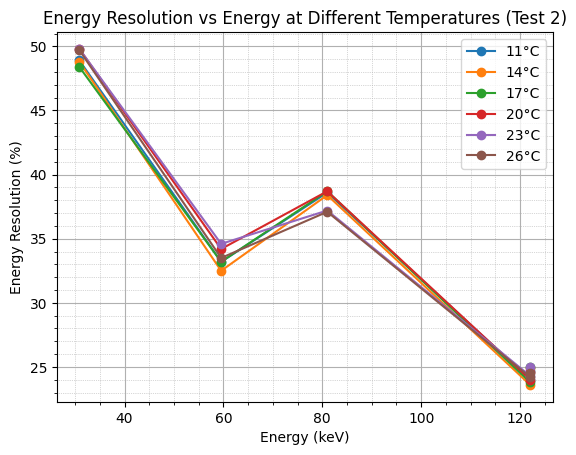

In [110]:
plt.plot(energies, df2_energy.loc[11].values, 'o-', label='11°C')
plt.plot(energies, df2_energy.loc[14].values, 'o-', label='14°C')
plt.plot(energies, df2_energy.loc[17].values, 'o-', label='17°C')
plt.plot(energies, df2_energy.loc[20].values, 'o-', label='20°C')
plt.plot(energies, df2_energy.loc[23].values, 'o-', label='23°C')
plt.plot(energies, df2_energy.loc[26].values, 'o-', label='26°C')
plt.xlabel('Energy (keV)')
plt.ylabel('Energy Resolution (%)')
plt.title('Energy Resolution vs Energy at Different Temperatures (Test 2)')
plt.minorticks_on()
plt.grid(which='both')
plt.grid(which='minor', linestyle=':', linewidth='0.5')
plt.legend()

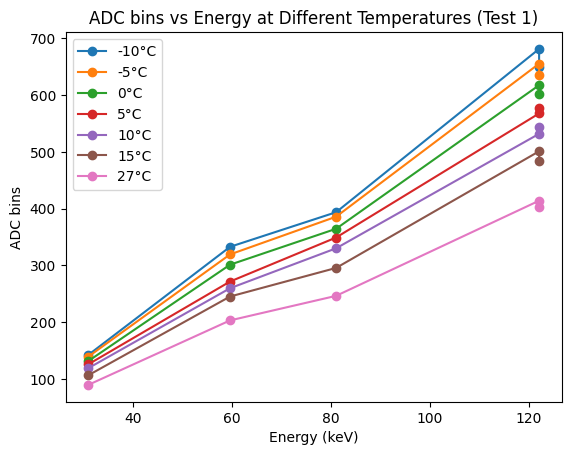

In [111]:
plt.plot(energies, df.loc[-10].values, 'o-', label='-10°C')
plt.plot(energies, df.loc[-5].values, 'o-', label='-5°C')
plt.plot(energies, df.loc[0].values, 'o-', label='0°C')
plt.plot(energies, df.loc[5].values, 'o-', label='5°C')
plt.plot(energies, df.loc[10].values, 'o-', label='10°C')
plt.plot(energies, df.loc[15].values, 'o-', label='15°C')
plt.plot(energies, df.loc[27].values, 'o-', label='27°C')
plt.xlabel('Energy (keV)')
plt.ylabel('ADC bins')
plt.title('ADC bins vs Energy at Different Temperatures (Test 1)')
plt.legend()

In [112]:
df.loc[-10]

Peaks_30keV       142.1
Peaks_60keV       332.8
Peaks_81keV       393.8
Peaks_122keV      681.6
Peaks_122keV_2    649.3
Name: -10, dtype: float64

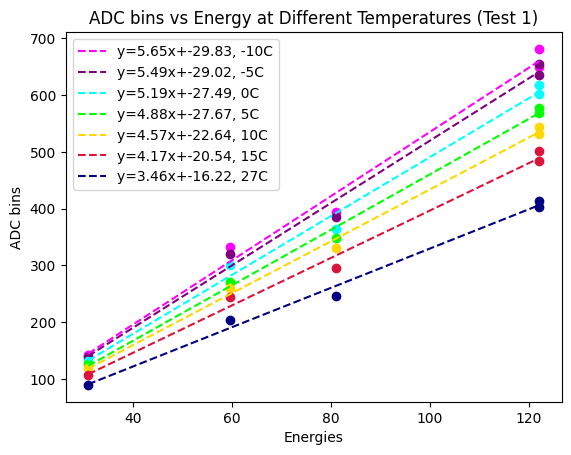

In [113]:
from sklearn.linear_model import LinearRegression
x = np.array(energies).reshape(-1,1)
yn10 = np.array(df.loc[-10])
yn5 = np.array(df.loc[-5])
y0 = np.array(df.loc[0])
y5 = np.array(df.loc[5])
y10 = np.array(df.loc[10])
y15 = np.array(df.loc[15])
y27 = np.array(df.loc[27])
modeln10 = LinearRegression().fit(x, yn10)
modeln5 = LinearRegression().fit(x, yn5)
model0 = LinearRegression().fit(x, y0)
model5 = LinearRegression().fit(x, y5)
model10 = LinearRegression().fit(x, y10)
model15 = LinearRegression().fit(x, y15)
model27 = LinearRegression().fit(x, y27)

interceptn10 = modeln10.intercept_
interceptn5 = modeln5.intercept_
intercept0 = model0.intercept_
intercept5 = model5.intercept_
intercept10 = model10.intercept_
intercept15 = model15.intercept_
intercept27 = model27.intercept_

slope1 = modeln10.coef_[0]
slope2 = modeln5.coef_[0]
slope3 = model0.coef_[0]
slope4 = model5.coef_[0]
slope5 = model10.coef_[0]
slope6 = model15.coef_[0]
slope7 = model27.coef_[0]

plt.scatter(energies, yn10, color='magenta')
plt.plot(energies, slope1*np.array(energies)+interceptn10, '--',label=f'y={slope1:.2f}x+{interceptn10:.2f}, -10C', color='magenta')
plt.scatter(energies, yn5, color='purple')
plt.plot(energies, slope2*np.array(energies)+interceptn5, '--',label=f'y={slope2:.2f}x+{interceptn5:.2f}, -5C', color='purple')
plt.scatter(energies, y0, color='cyan')
plt.plot(energies, slope3*np.array(energies)+intercept0, '--',label=f'y={slope3:.2f}x+{intercept0:.2f}, 0C', color='cyan')
plt.scatter(energies, y5, color='lime')
plt.plot(energies, slope4*np.array(energies)+intercept5, '--',label=f'y={slope4:.2f}x+{intercept5:.2f}, 5C', color='lime')
plt.scatter(energies, y10, color='gold')
plt.plot(energies, slope5*np.array(energies)+intercept10, '--',label=f'y={slope5:.2f}x+{intercept10:.2f}, 10C', color='gold')
plt.scatter(energies, y15, color='crimson')
plt.plot(energies, slope6*np.array(energies)+intercept15, '--',label=f'y={slope6:.2f}x+{intercept15:.2f}, 15C', color='crimson')
plt.scatter(energies, y27, color='navy')
plt.plot(energies, slope7*np.array(energies)+intercept27, '--',label=f'y={slope7:.2f}x+{intercept27:.2f}, 27C', color='navy')
plt.xlabel('Energies')
plt.ylabel('ADC bins')
plt.title('ADC bins vs Energy at Different Temperatures (Test 1)')
plt.legend()

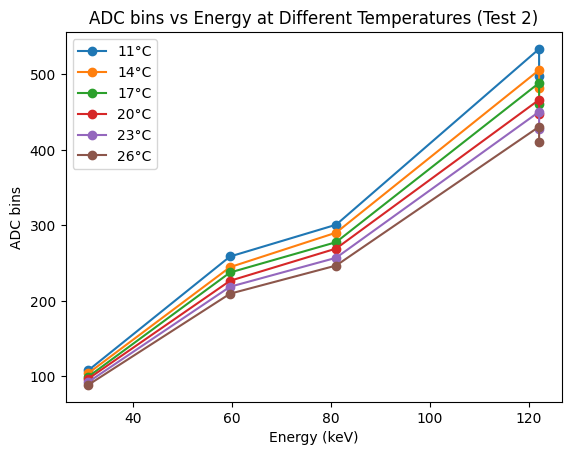

In [114]:
plt.plot(energies, df2.loc[11].values, 'o-', label='11°C')
plt.plot(energies, df2.loc[14].values, 'o-', label='14°C')
plt.plot(energies, df2.loc[17].values, 'o-', label='17°C')
plt.plot(energies, df2.loc[20].values, 'o-', label='20°C')
plt.plot(energies, df2.loc[23].values, 'o-', label='23°C')
plt.plot(energies, df2.loc[26].values, 'o-', label='26°C')
plt.xlabel('Energy (keV)')
plt.ylabel('ADC bins')
plt.title('ADC bins vs Energy at Different Temperatures (Test 2)')
plt.legend()

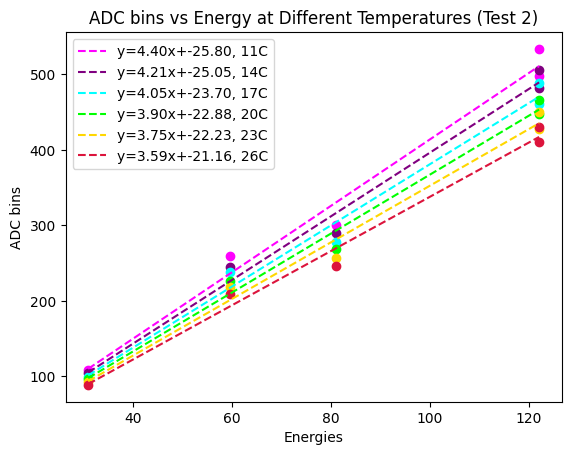

In [115]:
from sklearn.linear_model import LinearRegression
x = np.array(energies).reshape(-1,1)
y11 = np.array(df2.loc[11])
y14 = np.array(df2.loc[14])
y17 = np.array(df2.loc[17])
y20 = np.array(df2.loc[20])
y23 = np.array(df2.loc[23])
y26 = np.array(df2.loc[26])
model1 = LinearRegression().fit(x, y11)
model2 = LinearRegression().fit(x, y14)
model3 = LinearRegression().fit(x, y17)
model4 = LinearRegression().fit(x, y20)
model5 = LinearRegression().fit(x, y23)
model6 = LinearRegression().fit(x, y26)

intercept1 = model1.intercept_
intercept2 = model2.intercept_
intercept3 = model3.intercept_
intercept4 = model4.intercept_
intercept5 = model5.intercept_
intercept6 = model6.intercept_

slope1 = model1.coef_[0]
slope2 = model2.coef_[0]
slope3 = model3.coef_[0]
slope4 = model4.coef_[0]
slope5 = model5.coef_[0]
slope6 = model6.coef_[0]

plt.scatter(energies, y11, color='magenta')
plt.plot(energies, slope1*np.array(energies)+intercept1, '--',label=f'y={slope1:.2f}x+{intercept1:.2f}, 11C', color='magenta')
plt.scatter(energies, y14, color='purple')
plt.plot(energies, slope2*np.array(energies)+intercept2, '--',label=f'y={slope2:.2f}x+{intercept2:.2f}, 14C', color='purple')
plt.scatter(energies, y17, color='cyan')
plt.plot(energies, slope3*np.array(energies)+intercept3, '--',label=f'y={slope3:.2f}x+{intercept3:.2f}, 17C', color='cyan')
plt.scatter(energies, y20, color='lime')
plt.plot(energies, slope4*np.array(energies)+intercept4, '--',label=f'y={slope4:.2f}x+{intercept4:.2f}, 20C', color='lime')
plt.scatter(energies, y23, color='gold')
plt.plot(energies, slope5*np.array(energies)+intercept5, '--',label=f'y={slope5:.2f}x+{intercept5:.2f}, 23C', color='gold')
plt.scatter(energies, y26, color='crimson')
plt.plot(energies, slope6*np.array(energies)+intercept6, '--',label=f'y={slope6:.2f}x+{intercept6:.2f}, 26C', color='crimson')
plt.xlabel('Energies')
plt.ylabel('ADC bins')
plt.title('ADC bins vs Energy at Different Temperatures (Test 2)')
plt.legend()

### Extrapolations

In [116]:
spectra_types_1_T = [10, 15, 20, 27]
spectra_types_2_T = [-10, -5, 0, 5]
Temps = spectra_types_2_T + spectra_types_1_T
Temps

[-10, -5, 0, 5, 10, 15, 20, 27]

In [117]:
Temps, spectra_temps

([-10, -5, 0, 5, 10, 15, 20, 27], [11, 14, 17, 20, 23, 26])

In [131]:
combined = pd.concat([df, df2])
combined_df = combined.sort_index()

In [132]:
df_clean = combined_df[~combined_df.index.duplicated(keep='last')]

In [136]:
# df_clean

In [134]:
df_clean['Peaks_122keV_avg'] = df_clean[['Peaks_122keV', 'Peaks_122keV_2']].mean(axis=1).values
df_cleaned = df_clean.drop(columns=['Peaks_122keV', 'Peaks_122keV_2'])

In [149]:
# df_cleaned

interpolate

In [138]:
temp_range = np.arange(-10, 28, 1)
df_interpolated = df_cleaned.reindex(temp_range).interpolate(method='linear')

In [140]:
# df_interpolated

interpolate and extrapolate with scipy

In [141]:
from scipy.interpolate import interp1d

extended_temp_range = np.arange(-20, 35, 0.1)

f = interp1d(df_cleaned.index, df_cleaned.values, axis=0,
             kind='linear', fill_value='extrapolate')

extrapolated_values = f(extended_temp_range)

df_extrap = pd.DataFrame(extrapolated_values, index=extended_temp_range, columns=df_cleaned.columns)

In [148]:
df_extrap.to_clipboard(sep='\t', index=True)

In [151]:
# df_extrap

Interpolated over energies

In [152]:
energies

[30.85, 59.54, 81, 122.06, 122.06]

In [ ]:
adc_values = df_extrap.values

array([[148.1  , 359.6  , 409.6  , 704.25 ],
       [148.04 , 359.332, 409.442, 703.862],
       [147.98 , 359.064, 409.284, 703.474],
       ...,
       [ 96.33 , 154.59 , 244.09 , 317.32 ],
       [ 96.42 , 153.96 , 244.06 , 316.13 ],
       [ 96.51 , 153.33 , 244.03 , 314.94 ]], shape=(550, 4))

In [176]:
target_energies = np.arange(10,151,1)
interp_rows = []

for temp, row in df_extrap.iterrows():
    f_energies = interp1d(energies[:4], row.values, kind='linear', fill_value='extrapolate')
    interp_rows.append(f_energies(target_energies))

In [177]:
df_energies = pd.DataFrame(
    interp_rows,
    index = df_extrap.index,
    columns = [e for e in target_energies]
)

In [178]:
df_energies

,10,11,12,13,14,15,16,17,18,19,...,141,142,143,144,145,146,147,148,149,150
-20.0,-5.604252,1.767654,9.139561,16.511467,23.883374,31.255281,38.627187,45.999094,53.371000,60.742907,...,840.165027,847.341111,854.517194,861.693278,868.869362,876.045446,883.221529,890.397613,897.573697,904.749781
-19.9,-5.513092,1.851565,9.216222,16.580878,23.945535,31.310192,38.674848,46.039505,53.404162,60.768818,...,839.670933,846.841415,854.011898,861.182380,868.352862,875.523344,882.693827,889.864309,897.034791,904.205273
-19.8,-5.421931,1.935476,9.292883,16.650289,24.007696,31.365103,38.722510,46.079916,53.437323,60.794730,...,839.176840,846.341720,853.506601,860.671482,867.836362,875.001243,882.166124,889.331004,896.495885,903.660766
-19.7,-5.330770,2.019387,9.369543,16.719700,24.069857,31.420014,38.770171,46.120328,53.470484,60.820641,...,838.682746,845.842025,853.001304,860.160584,867.319863,874.479142,881.638421,888.797700,895.956979,903.116258
-19.6,-5.239610,2.103297,9.446204,16.789111,24.132018,31.474925,38.817832,46.160739,53.503646,60.846553,...,838.188653,845.342330,852.496008,859.649685,866.803363,873.957040,881.110718,888.264396,895.418073,902.571751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34.5,52.763977,54.844841,56.925706,59.006570,61.087435,63.168299,65.249163,67.330028,69.410892,71.491757,...,354.549415,356.389406,358.229396,360.069386,361.909377,363.749367,365.589357,367.429347,369.269338,371.109328
34.6,53.377226,55.432994,57.488763,59.544531,61.600300,63.656068,65.711837,67.767605,69.823374,71.879143,...,352.824335,354.636074,356.447813,358.259552,360.071291,361.883030,363.694769,365.506508,367.318246,369.129985
34.7,53.990474,56.021147,58.051819,60.082492,62.113165,64.143838,66.174510,68.205183,70.235856,72.266528,...,351.099255,352.882742,354.666230,356.449717,358.233205,360.016693,361.800180,363.583668,365.367155,367.150643
34.8,54.603723,56.609299,58.614876,60.620453,62.626030,64.631607,66.637184,68.642761,70.648337,72.653914,...,349.374174,351.129411,352.884647,354.639883,356.395119,358.150356,359.905592,361.660828,363.416064,365.171301


In [179]:
df_energies_resort = df_energies.sort_index(ascending=False)

In [181]:
# df_energies_resort

In [182]:
df_energies_resort.to_clipboard(sep='\t')

### Waveforms

In [39]:
wf_path = find_E_path / 'wf'
wff = sorted(wf_path.glob('*.bin'))
print(wff)

[PosixPath('calibration/T_gain_curve/find_14_122keV/wf/38V_Co57.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/wf/39V_Co57.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/wf/40V_Co57.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/wf/43V_Co57.bin'), PosixPath('calibration/T_gain_curve/find_14_122keV/wf/45V_Co57.bin')]


In [40]:
PACKET_SIZE = 8000
waveforms_ = []

for fn in wff:
    waveforms = wf_parse(fn, PACKET_SIZE)
    waveforms_.append(waveforms)

print(len(waveforms))

3000


In [41]:
wf39V_co57=waveforms_[1]
wf40V_co57=waveforms_[2]
wf43V_co57=waveforms_[3]
wf45V_co57=waveforms_[4]

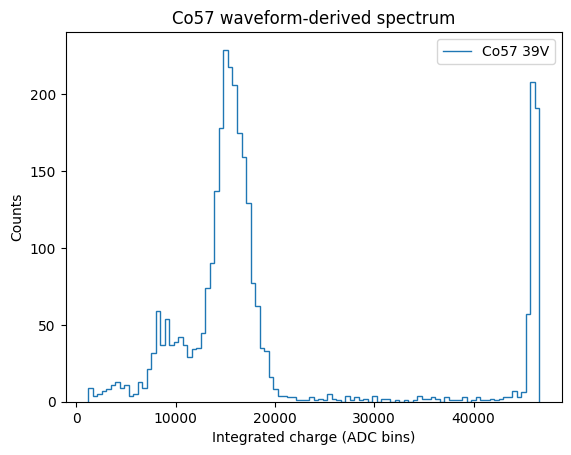

In [42]:
# waveform = np.array(waveforms_[0]['data'])
hg_am, bins_am = np.histogram(get_charge(wf39V_co57), bins = 100)

fig, ax = plt.subplots()
ax.stairs(hg_am, bins_am, label='Co57 39V')
ax.set_xlabel("Integrated charge (ADC bins)")
ax.set_ylabel("Counts")
ax.set_title("Co57 waveform-derived spectrum")
plt.legend()
plt.show()

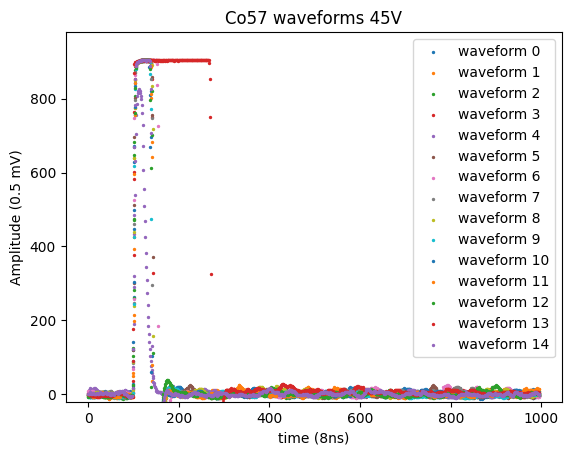

In [43]:
selection = random.choices(waveforms_[4], k=15) # choose wf
t = np.arange(len(selection[0]['data']))
waveform = np.array(selection[0]['data'])

fig, ax = plt.subplots()
for i, s in enumerate(selection):
    ax.scatter(t, s['data'], 2, label=f'waveform {i}')
    # ax.set_xlim(80, 600)
    ax.set_ylim(-20,980)
    plt.legend()
ax.set_xlabel('time (8ns)')
ax.set_ylabel('Amplitude (0.5 mV)')
plt.title('Co57 waveforms 45V')
plt.show()

### OThers

In [44]:
fn39 = sorted(cal39.glob('spectra*'))
PACKET_SIZE = 8000
spec39 = []
for fn in fn39:    
    spectra = spec_parse(fn, PACKET_SIZE)
    spec39.append(spectra)

print(spectra.shape)

fn38 = sorted(cal38.glob('spectra*'))
PACKET_SIZE = 8000
spec38 = []
for fn in fn38:    
    spectra = spec_parse(fn, PACKET_SIZE)
    spec38.append(spectra)

print(spectra.shape)

NameError: name 'cal39' is not defined

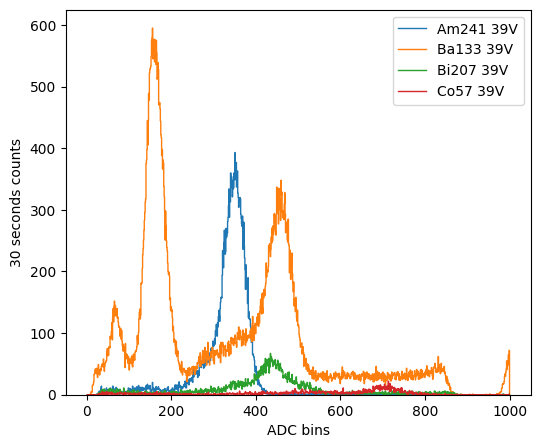

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
bins = np.arange(1001)

ax.stairs(spec39[0].sum(axis=0)[3], bins, label=f'Am241 39V')
ax.stairs(spec39[1].sum(axis=0)[3], bins, label=f'Ba133 39V')
ax.stairs(spec39[2].sum(axis=0)[3], bins, label=f'Bi207 39V')
ax.stairs(spec39[3].sum(axis=0)[3], bins, label=f'Co57 39V')
ax.set_xlabel('ADC bins')
ax.set_ylabel('30 seconds counts')
ax.legend()

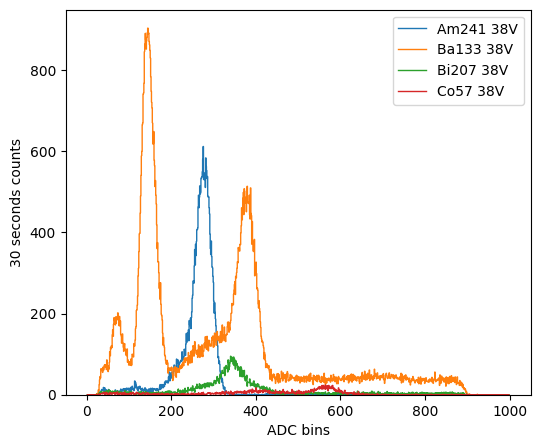

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
bins = np.arange(1001)

ax.stairs(spec38[0].sum(axis=0)[3], bins, label=f'Am241 38V')
ax.stairs(spec38[1].sum(axis=0)[3], bins, label=f'Ba133 38V')
ax.stairs(spec38[2].sum(axis=0)[3], bins, label=f'Bi207 38V')
ax.stairs(spec38[3].sum(axis=0)[3], bins, label=f'Co57 38V')
ax.set_xlabel('ADC bins')
ax.set_ylabel('30 seconds counts')
ax.legend()

In [ ]:
specs = []
for i in spec38:
    specs.append(i)
for j in spec39:
    specs.append(j) # combination of 38 and 39 voltages

In [ ]:
labels = ['Am241 60keV 38V', 'Ba133 80 keV 38V', 'Bi207 74-75keV 38V', 'Co57 122keV 38V', 'Am241 60keV 39V', 'Ba133 80keV 39V', 'Bi207 74-75keV 39V', 'Co57 122keV 39V']

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_31831/2003746843.py:20: SyntaxWarning: invalid escape sequence '\m'
  axis.plot(mids, gauss(mids, *po), label=f'ER={fwhm:.1f}% FWHM, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')


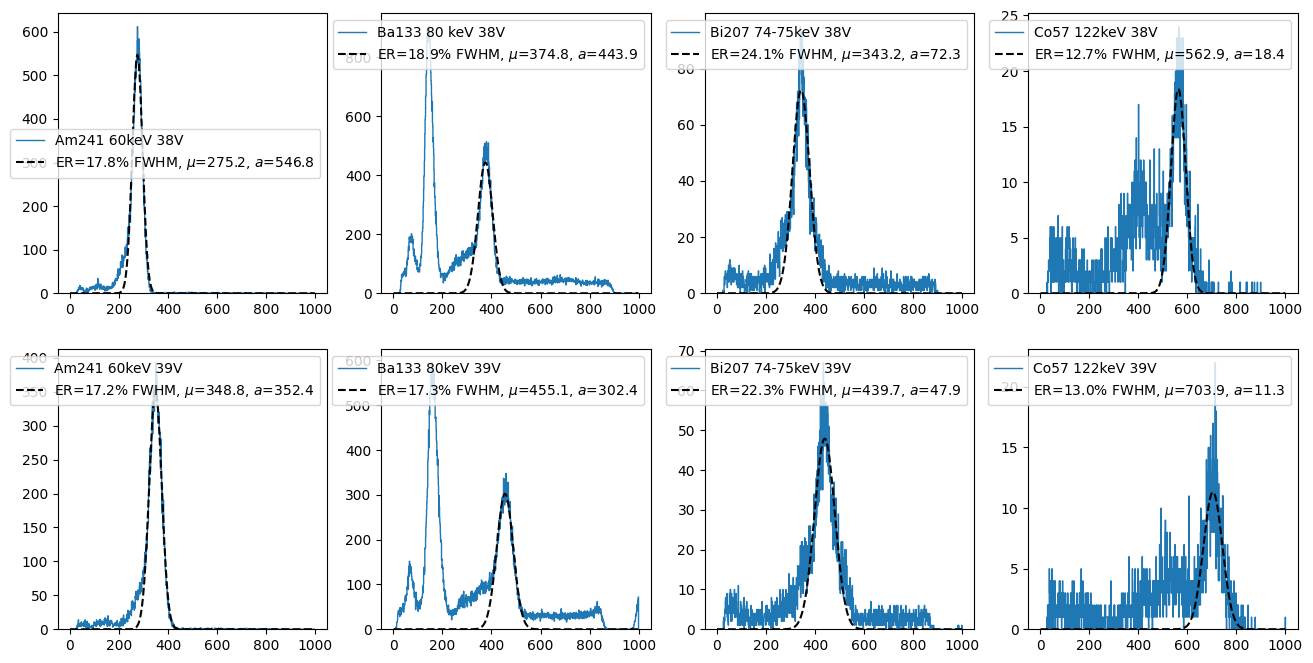

In [ ]:
fig, ax = plt.subplots(2,4, figsize=(16,8))
bins = np.arange(1001)

range_ = [[200, 320], [300, 420], [250, 400], [500, 620], [300, 400], [400, 540], [380, 550], [620, 780]]
mu_ = [250, 370, 330, 580, 300, 480, 400, 700, 750, 400, 500, 600, 600, 100, 100]
amp = [400, 350, 50, 20, 400, 350, 50, 20, 300, 250, 250, 250, 250, 250, 250]
w_ = [50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50]

for i, axis in enumerate(ax.flatten()):
    mids = bins[:-1] + np.diff(bins)/2
    range = (mids >= range_[i][0]) & (mids <= range_[i][1])

    summation = specs[i].sum(axis=0)[3]

    po, pc = sco.curve_fit(gauss, mids[range], summation[range], p0=[mu_[i], amp[i], w_[i]]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)

    axis.stairs(summation, bins, label=f'{labels[i]}')
    axis.plot(mids, gauss(mids, *po), label=f'ER={fwhm:.1f}% FWHM, $\mu$={mu:.1f}, $a$={a:.1f}', color='black', linestyle='dashed')
    axis.legend()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_31831/2275236711.py:22: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(mids, gauss(mids, *po), label=f'ER={fwhm:.1f}% FWHM, $\mu$={mu:.1f}, $a$={a:.1f}', color=colors[i], linestyle='dashed')


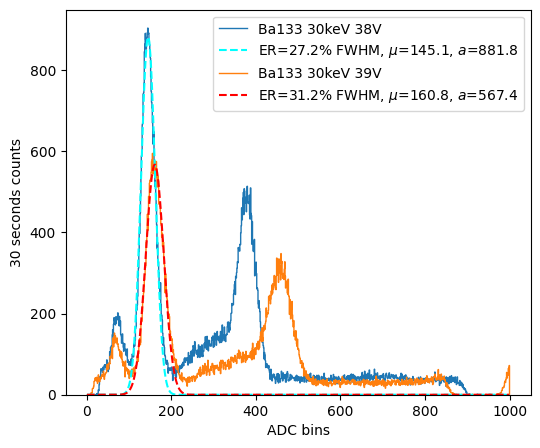

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
bins = np.arange(1001)
labels = ['Ba133 30keV 38V', 'Ba133 30keV 39V']
range_ = [[100, 180], [120, 200]]
mu_ = [140, 160]
amp = [900, 600]
colors = ['cyan', 'red']
spec30keV = [spec38[1].sum(axis=0)[3], spec39[1].sum(axis=0)[3]]


for i in np.arange(len(amp)):
    mids = bins[:-1] + np.diff(bins)/2
    range = (mids >= range_[i][0]) & (mids <= range_[i][1])

    summation = spec30keV[i]

    po, pc = sco.curve_fit(gauss, mids[range], summation[range], p0=[mu_[i], amp[i], 10]) # p0: mu, amplitude, w=SD
    mu, a, w = po
    fwhm = np.abs((2 * np.sqrt(np.log(2)) * w / mu) * 100)
    
    ax.stairs(summation, bins, label=f'{labels[i]}')
    ax.plot(mids, gauss(mids, *po), label=f'ER={fwhm:.1f}% FWHM, $\mu$={mu:.1f}, $a$={a:.1f}', color=colors[i], linestyle='dashed')

ax.set_xlabel('ADC bins')
ax.set_ylabel('30 seconds counts')
plt.legend()

In [ ]:
energies = [30, 60, 80, 122]
mu38 = [145.1, 275.2, 374.8, 562.9]
mu39 = [160.8, 348.8, 455.1, 703.9]

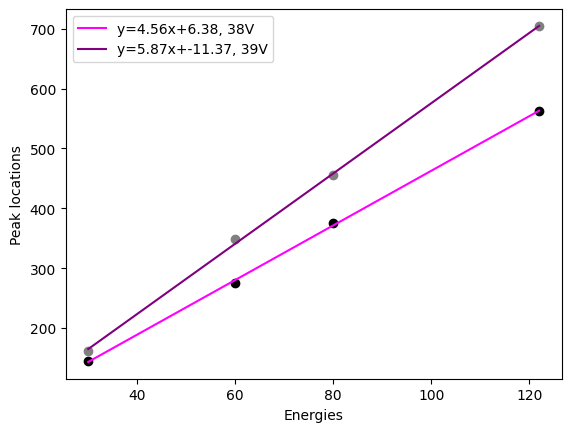

In [ ]:
from sklearn.linear_model import LinearRegression
x = np.array(energies).reshape(-1,1)
y1 = np.array(mu38)
y2 = np.array(mu39)
model1 = LinearRegression().fit(x, y1)
model2 = LinearRegression().fit(x, y2)

intercept1 = model1.intercept_
intercept2 = model2.intercept_
slope1 = model1.coef_[0]
slope2 = model2.coef_[0]

plt.scatter(energies, mu38, color='black')
plt.plot(energies, slope1*np.array(energies)+intercept1, label=f'y={slope1:.2f}x+{intercept1:.2f}, 38V', color='magenta')
plt.scatter(energies, mu39, color='grey')
plt.plot(energies, slope2*np.array(energies)+intercept2, label=f'y={slope2:.2f}x+{intercept2:.2f}, 39V', color='purple')
plt.xlabel('Energies')
plt.ylabel('Peak locations')
plt.legend()

### Background

In [ ]:
wf_data = Path('calibration/lyso/wf')
sp_data = Path('calibration/lyso/sp')

In [ ]:
wff = sorted(wf_data.glob('*.bin'))
spp = sorted(sp_data.glob('*.bin'))
print(wff, spp)

[PosixPath('calibration/lyso/wf/wf_39V_lyso.bin'), PosixPath('calibration/lyso/wf/wf_40V_lyso.bin')] [PosixPath('calibration/lyso/sp/39V_lyso_bkg.bin'), PosixPath('calibration/lyso/sp/40V_lyso_bkg.bin')]


In [ ]:
wfs = []
for fn in wff:
    waveforms = wf_parse(fn, 8000)
    wfs.append(waveforms)

print(len(wfs))

2


In [ ]:
spectra_v = []

for fn in spp:
    spectra = spec_parse(fn, 8000)
    spectra_v.append(spectra)

print('There are spectra for', len(spectra_v), 'bias voltages')

There are spectra for 2 bias voltages


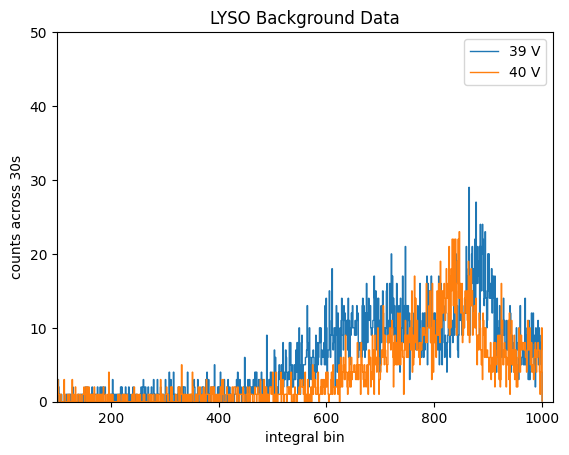

In [ ]:
bins = np.arange(1001)
label = ['39 V', '40 V']

fig, ax = plt.subplots()

for i in np.arange(2):
    spectra = np.array(spectra_v[i])
    summation = spectra.sum(axis=0)[3]
    ax.stairs(summation, bins, label=label[i])
ax.set(xlabel='integral bin', ylabel=f'counts across {(32*30) // 32}s', title='LYSO Background Data')
ax.set_xlim(100, 1020)
ax.set_ylim(0, 50)
ax.legend()
plt.show()

In [ ]:
wf_lyso_bkg = wfs[0]
selection = random.choices(wf_lyso_bkg, k=10)
t = np.arange(len(selection[0]['data']))
waveform = np.array(selection[0]['data'])

fig, ax = plt.subplots()
for i, s in enumerate(selection):
    ax.scatter(t, s['data'], 2, label=f'waveform {i}')
    # ax.set_xlim(80, 250)
    # ax.set_ylim(-20,100)
    plt.legend()
ax.set_xlabel('time (8ns)')
ax.set_ylabel('Amplitude (1 mV)')
plt.title('LYSO bkg waveforms')
plt.show()